# Feature Build `_Xy_all.parquet` Artifact Review

목적: feature build 완료 산출물인 `_Xy_all.parquet` 1개를 대상으로 학습 전 데이터 품질, split drift, label separation, 신규 피처 분포를 전체 parquet 기준으로 점검한다.

사용 방법:

1. 바로 아래 `사용자 입력값` 셀에서 `EXPORT_EXPERIMENT_ID`, `RUN_ID`, `TARGET_PARQUET_PATH`를 확인 대상 파일로 맞춘다.
2. contract, manifest, feature types 경로를 직접 지정하지 않으면 같은 폴더의 sibling artifact를 자동 탐색한다.
3. 이 노트북은 `_Xy_all.parquet`를 parquet batch로 끝까지 읽어 exact summary를 계산한다.
4. 파일 복사, 승인, 재생성, overwrite는 수행하지 않는다.


In [1]:
from pathlib import Path

# ============================================================
# 사용자 입력값: 보려는 feature build 산출물이 바뀌면 이 셀만 수정
# ============================================================

LOCAL_REPO_ROOT = Path("/mnt/d/AML_git/Graph_AML").resolve()

def normalize_experiment_id(value: str) -> str:
    token = str(value).strip().lower().replace("-", "_")
    if token.isdigit():
        token = f"ml_{token.zfill(2)}"
    if not token.startswith("ml_"):
        raise ValueError(f"EXPORT_EXPERIMENT_ID must look like 'ml_05', 'ml-05', or '05': {value!r}")
    suffix = token.removeprefix("ml_")
    if not suffix.isdigit():
        raise ValueError(f"EXPORT_EXPERIMENT_ID has a non-numeric suffix: {value!r}")
    return f"ml_{suffix.zfill(2)}"


EXPORT_EXPERIMENT_ID = normalize_experiment_id("ml_05")
RUN_ID = "r00"
EXPERIMENT_DIR_NAME = EXPORT_EXPERIMENT_ID.replace("_", "-")
ARTIFACT_PREFIX = f"{EXPORT_EXPERIMENT_ID}__{RUN_ID}"

TARGET_PARQUET_PATH = (
    LOCAL_REPO_ROOT
    / "ml"
    / EXPERIMENT_DIR_NAME
    / "fb_outputs"
    / RUN_ID
    / f"{ARTIFACT_PREFIX}_Xy_all.parquet"
)

# 필요 시 직접 지정한다. None이면 TARGET_PARQUET_PATH와 같은 폴더에서 자동 탐색한다.
CONTRACT_PATH = None
ENCODING_MANIFEST_PATH = None
FEATURE_TYPES_PATH = None
FEATURE_INFO_PATH = None
SPLIT_SUMMARY_PATH = None

TOP_N = 30
PREVIEW_ROW_COUNT = 10
TIME_BIN_FREQ = "6h"
BATCH_SIZE = 262_144


In [2]:
from __future__ import annotations

import json
import math
import os
import re
import subprocess
from collections import Counter, defaultdict
from datetime import datetime
from pathlib import Path
from typing import Any, Optional
from zoneinfo import ZoneInfo

MPLCONFIGDIR = Path("/tmp/matplotlib-codex-cache")
MPLCONFIGDIR.mkdir(parents=True, exist_ok=True)
os.environ.setdefault("MPLCONFIGDIR", str(MPLCONFIGDIR))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyarrow.parquet as pq
from IPython.display import Markdown, display

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_colwidth", 180)
pd.set_option("display.width", 220)


In [3]:
LABEL_PREFERRED_NAMES = ["label", "target", "y", "is_laundering", "is laundering"]
SPLIT_PREFERRED_NAMES = ["split", "dataset_split", "data_split"]
TIME_PREFERRED_NAMES = ["timestamp", "time", "datetime", "event_time", "created_at"]
FORBIDDEN_FEATURE_PATTERNS = ("laundering", "pattern", "typology", "attempt")
KNOWN_NON_FEATURE_COLUMNS = {
    "tx_id",
    "timestamp",
    "Timestamp",
    "split",
    "label",
    "target",
    "y",
    "sender_account",
    "receiver_account",
    "sender_account_id",
    "receiver_account_id",
    "Account",
    "Account.1",
    "From Bank",
    "To Bank",
    "Is Laundering",
}
SPLIT_ORDER = ["train", "val", "test"]
LABEL_ORDER = [0, 1]


def normalize_name(name: str) -> str:
    return re.sub(r"[^0-9a-zA-Z]+", "_", str(name).strip().lower()).strip("_")


def normalize_bool(value: Any) -> bool:
    if pd.isna(value):
        return False
    if isinstance(value, (bool, np.bool_)):
        return bool(value)
    return str(value).strip().lower() in {"true", "1", "yes", "y", "t"}


def optional_path(value: Any) -> Optional[Path]:
    if value is None:
        return None
    text = str(value).strip()
    if text == "":
        return None
    return Path(text).expanduser().resolve()


def suggest_existing_experiment_path(path: Path) -> Optional[Path]:
    parts = list(path.parts)
    for idx, part in enumerate(parts[:-1]):
        if part != "ml" or idx + 1 >= len(parts):
            continue
        experiment_dir = parts[idx + 1]
        normalized = experiment_dir.lower().replace("_", "-")
        candidate_dir = None
        if normalized != experiment_dir:
            candidate_dir = normalized
        elif normalized.isdigit():
            candidate_dir = f"ml-{normalized.zfill(2)}"
        elif normalized.startswith("ml") and normalized[2:].isdigit():
            candidate_dir = f"ml-{normalized[2:].zfill(2)}"
        if candidate_dir is None or candidate_dir == experiment_dir:
            continue
        candidate = Path(*parts[: idx + 1], candidate_dir, *parts[idx + 2 :])
        if candidate.exists():
            return candidate
    return None


def infer_artifact_prefix(path: Path) -> str:
    suffix = "_Xy_all.parquet"
    if not path.name.endswith(suffix):
        raise ValueError(f"TARGET_PARQUET_PATH must end with {suffix!r}: {path}")
    return path.name[: -len(suffix)]


def first_existing(paths: list[Path]) -> Optional[Path]:
    existing = [path for path in paths if path.exists()]
    return existing[0] if existing else None


def infer_sibling_artifacts(target_path: Path, prefix: str) -> dict[str, Optional[Path]]:
    base_dir = target_path.parent
    candidates = {
        "contract": [
            base_dir / f"{prefix}_fb_output_feature_contract.csv",
            base_dir / f"{prefix}_feature_contract.csv",
            base_dir / f"{prefix}_feature_contract_approve.csv",
            base_dir / f"{prefix}_fb_output_feature_contract_approve.csv",
            base_dir / f"{prefix}_ml_feature_columns_approve.csv",
            base_dir / f"{prefix}_ml_feature_columns.csv",
        ],
        "encoding_manifest": [base_dir / f"{prefix}_encoding_manifest.json"],
        "feature_types": [base_dir / f"{prefix}_feature_types.json"],
        "feature_info": [base_dir / f"{prefix}_feature_info.csv"],
        "split_summary": [base_dir / f"{prefix}_split_summary.csv"],
    }
    return {name: first_existing(path_list) for name, path_list in candidates.items()}


def load_json(path: Optional[Path]) -> Optional[dict[str, Any]]:
    if path is None:
        return None
    with path.open("r", encoding="utf-8") as f:
        data = json.load(f)
    if not isinstance(data, dict):
        raise TypeError(f"JSON root must be an object: {path}")
    return data


def load_csv(path: Optional[Path]) -> Optional[pd.DataFrame]:
    if path is None:
        return None
    return pd.read_csv(path)


def run_git_command(args: list[str]) -> Optional[str]:
    try:
        result = subprocess.run(
            ["git", *args],
            cwd=LOCAL_REPO_ROOT,
            check=True,
            stdout=subprocess.PIPE,
            stderr=subprocess.PIPE,
            text=True,
        )
    except (subprocess.CalledProcessError, FileNotFoundError):
        return None
    return result.stdout.strip()


def execution_provenance(path: Path) -> pd.DataFrame:
    git_hash = run_git_command(["rev-parse", "HEAD"])
    git_status = run_git_command(["status", "--short"])
    stat = path.stat()
    return pd.DataFrame(
        [
            {
                "executed_at_kst": datetime.now(ZoneInfo("Asia/Seoul")).isoformat(timespec="seconds"),
                "target_path": str(path),
                "artifact_mtime_kst": datetime.fromtimestamp(stat.st_mtime, ZoneInfo("Asia/Seoul")).isoformat(timespec="seconds"),
                "artifact_size_mb": round(stat.st_size / 1024 / 1024, 2),
                "git_hash": git_hash,
                "git_worktree_dirty": bool(git_status),
            }
        ]
    )


def parquet_overview(path: Path) -> tuple[pq.ParquetFile, pd.DataFrame, pd.DataFrame]:
    pf = pq.ParquetFile(path)
    metadata = pf.metadata
    overview_df = pd.DataFrame(
        [
            {
                "path": str(path),
                "file_size_mb": round(path.stat().st_size / 1024 / 1024, 2),
                "num_rows": metadata.num_rows,
                "num_columns": metadata.num_columns,
                "num_row_groups": metadata.num_row_groups,
                "created_by": metadata.created_by,
            }
        ]
    )
    schema_rows = []
    for idx, field in enumerate(pf.schema_arrow):
        schema_rows.append(
            {
                "idx": idx,
                "column_name": field.name,
                "arrow_type": str(field.type),
                "nullable": field.nullable,
            }
        )
    return pf, overview_df, pd.DataFrame(schema_rows)


def detect_special_columns(columns: list[str]) -> dict[str, list[str]]:
    label_normalized = {normalize_name(x) for x in LABEL_PREFERRED_NAMES}
    split_normalized = {normalize_name(x) for x in SPLIT_PREFERRED_NAMES}
    time_normalized = {normalize_name(x) for x in TIME_PREFERRED_NAMES}
    labels = []
    splits = []
    times = []
    forbidden = []
    for col in columns:
        normalized = normalize_name(col)
        if normalized in label_normalized:
            labels.append(col)
        if normalized in split_normalized:
            splits.append(col)
        if normalized in time_normalized or "timestamp" in normalized:
            times.append(col)
        if any(pattern in normalized for pattern in FORBIDDEN_FEATURE_PATTERNS):
            forbidden.append(col)
    return {"label": labels, "split": splits, "time": times, "forbidden": forbidden}


def choose_preferred_column(candidates: list[str], preferred_names: list[str]) -> Optional[str]:
    if not candidates:
        return None
    by_normalized = {}
    for col in candidates:
        by_normalized.setdefault(normalize_name(col), col)
    for name in preferred_names:
        normalized = normalize_name(name)
        if normalized in by_normalized:
            return by_normalized[normalized]
    return candidates[0]


def feature_types_columns(feature_types: Optional[dict[str, Any]]) -> list[str]:
    if feature_types is None:
        return []
    raw = feature_types.get("feature_types", feature_types)
    if isinstance(raw, dict):
        return list(raw.keys())
    return []


def manifest_feature_columns(manifest: Optional[dict[str, Any]]) -> list[str]:
    if manifest is None:
        return []
    columns = manifest.get("feature_columns", [])
    if isinstance(columns, list):
        return [str(col) for col in columns]
    return []


def contract_selected_columns(contract_df: Optional[pd.DataFrame]) -> list[str]:
    if contract_df is None:
        return []
    required = {"column_name", "used_in_ml"}
    if not required.issubset(contract_df.columns):
        return []
    mask = contract_df["used_in_ml"].map(normalize_bool)
    return contract_df.loc[mask, "column_name"].dropna().astype(str).tolist()


def infer_feature_columns(
    schema_columns: list[str],
    contract_df: Optional[pd.DataFrame],
    feature_types: Optional[dict[str, Any]],
    manifest: Optional[dict[str, Any]],
) -> tuple[list[str], str]:
    selected = contract_selected_columns(contract_df)
    if selected:
        return selected, "contract.used_in_ml"
    from_feature_types = feature_types_columns(feature_types)
    if from_feature_types:
        return from_feature_types, "feature_types"
    from_manifest = manifest_feature_columns(manifest)
    if from_manifest:
        return from_manifest, "encoding_manifest.feature_columns"
    inferred = []
    known_non_feature_normalized = {normalize_name(x) for x in KNOWN_NON_FEATURE_COLUMNS}
    for col in schema_columns:
        normalized = normalize_name(col)
        is_known_non_feature = col in KNOWN_NON_FEATURE_COLUMNS or normalized in known_non_feature_normalized
        is_forbidden = any(pattern in normalized for pattern in FORBIDDEN_FEATURE_PATTERNS)
        if not is_known_non_feature and not is_forbidden:
            inferred.append(col)
    return inferred, "schema_inferred"


def selected_contract_frame(contract_df: Optional[pd.DataFrame], selected_columns: list[str]) -> pd.DataFrame:
    if contract_df is None:
        return pd.DataFrame({"column_name": selected_columns})
    selected_set = set(selected_columns)
    return contract_df.loc[contract_df["column_name"].astype(str).isin(selected_set)].copy()


def feature_group_map(contract_df: Optional[pd.DataFrame], feature_columns: list[str]) -> dict[str, str]:
    if contract_df is not None and {"column_name", "feature_group"}.issubset(contract_df.columns):
        group_series = contract_df.set_index("column_name")["feature_group"]
        return {col: str(group_series.get(col, "unknown") or "unknown") for col in feature_columns}
    return {col: str(col).split("__", 1)[0] if "__" in str(col) else "unknown" for col in feature_columns}


def signed_log1p_array(values: np.ndarray) -> np.ndarray:
    return np.sign(values) * np.log1p(np.abs(values))


def safe_ratio(numerator: float, denominator: float) -> float:
    if denominator == 0 or pd.isna(denominator):
        return np.nan
    return numerator / denominator


def read_parquet_head(path: Path, columns: list[str], row_count: int) -> pd.DataFrame:
    pf = pq.ParquetFile(path)
    pieces = []
    remaining = row_count
    for batch in pf.iter_batches(batch_size=min(BATCH_SIZE, max(1, remaining)), columns=columns):
        pieces.append(batch.to_pandas())
        remaining -= batch.num_rows
        if remaining <= 0:
            break
    if not pieces:
        return pd.DataFrame(columns=columns)
    return pd.concat(pieces, ignore_index=True).head(row_count)


In [4]:
target_path = Path(TARGET_PARQUET_PATH).expanduser().resolve()
if not target_path.exists():
    suggested_path = suggest_existing_experiment_path(target_path)
    message = f"TARGET_PARQUET_PATH not found: {target_path}"
    if suggested_path is not None:
        message += f"\nExisting experiment path candidate: {suggested_path}"
    raise FileNotFoundError(message)

artifact_prefix = infer_artifact_prefix(target_path)
auto_paths = infer_sibling_artifacts(target_path, artifact_prefix)
artifact_paths = {
    "contract": optional_path(CONTRACT_PATH) or auto_paths["contract"],
    "encoding_manifest": optional_path(ENCODING_MANIFEST_PATH) or auto_paths["encoding_manifest"],
    "feature_types": optional_path(FEATURE_TYPES_PATH) or auto_paths["feature_types"],
    "feature_info": optional_path(FEATURE_INFO_PATH) or auto_paths["feature_info"],
    "split_summary": optional_path(SPLIT_SUMMARY_PATH) or auto_paths["split_summary"],
}

pf, overview_df, schema_df = parquet_overview(target_path)
schema_columns = schema_df["column_name"].tolist()
special_columns = detect_special_columns(schema_columns)
label_col = choose_preferred_column(special_columns["label"], LABEL_PREFERRED_NAMES)
split_col = choose_preferred_column(special_columns["split"], SPLIT_PREFERRED_NAMES)
time_col = choose_preferred_column(special_columns["time"], TIME_PREFERRED_NAMES)

if label_col is None:
    raise ValueError("No label-like column detected in parquet schema")
if split_col is None:
    raise ValueError("No split-like column detected in parquet schema")
if time_col is None:
    raise ValueError("No timestamp-like column detected in parquet schema")

display(Markdown("## 1. Run provenance"))
display(execution_provenance(target_path))

display(Markdown("## 2. Target parquet metadata"))
display(overview_df)

display(Markdown("## 3. Auto-resolved sibling artifacts"))
display(
    pd.DataFrame(
        [
            {"artifact": key, "path": str(path) if path is not None else None, "exists": bool(path and path.exists())}
            for key, path in artifact_paths.items()
        ]
    )
)

display(Markdown("## 4. Detected control columns"))
display(
    pd.DataFrame(
        [
            {"role": "label", "selected_column": label_col, "candidates": special_columns["label"]},
            {"role": "split", "selected_column": split_col, "candidates": special_columns["split"]},
            {"role": "timestamp", "selected_column": time_col, "candidates": special_columns["time"]},
            {"role": "forbidden_name_pattern", "selected_column": None, "candidates": special_columns["forbidden"]},
        ]
    )
)


## 1. Run provenance

,executed_at_kst,target_path,artifact_mtime_kst,artifact_size_mb,git_hash,git_worktree_dirty
0,2026-05-29T11:57:24+09:00,/mnt/d/AML_git/Graph_AML/ml/ml-05/fb_outputs/r00/ml_05__r00_Xy_all.parquet,2026-05-29T11:24:34+09:00,3208.59,b99788704d2f1076503c85294bc2d2b5b67b533c,True


## 2. Target parquet metadata

,path,file_size_mb,num_rows,num_columns,num_row_groups,created_by
0,/mnt/d/AML_git/Graph_AML/ml/ml-05/fb_outputs/r00/ml_05__r00_Xy_all.parquet,3208.59,5077237,275,5,parquet-cpp-arrow version 14.0.2


## 3. Auto-resolved sibling artifacts

,artifact,path,exists
0,contract,/mnt/d/AML_git/Graph_AML/ml/ml-05/fb_outputs/r00/ml_05__r00_fb_output_feature_contract.csv,True
1,encoding_manifest,/mnt/d/AML_git/Graph_AML/ml/ml-05/fb_outputs/r00/ml_05__r00_encoding_manifest.json,True
2,feature_types,/mnt/d/AML_git/Graph_AML/ml/ml-05/fb_outputs/r00/ml_05__r00_feature_types.json,True
3,feature_info,/mnt/d/AML_git/Graph_AML/ml/ml-05/fb_outputs/r00/ml_05__r00_feature_info.csv,True
4,split_summary,/mnt/d/AML_git/Graph_AML/ml/ml-05/fb_outputs/r00/ml_05__r00_split_summary.csv,True


## 4. Detected control columns

,role,selected_column,candidates
0,label,label,"[label, Is Laundering]"
1,split,split,[split]
2,timestamp,timestamp,"[timestamp, Timestamp]"
3,forbidden_name_pattern,None,[Is Laundering]


In [5]:
contract_df = load_csv(artifact_paths["contract"])
feature_info_df = load_csv(artifact_paths["feature_info"])
split_summary_df = load_csv(artifact_paths["split_summary"])
encoding_manifest = load_json(artifact_paths["encoding_manifest"])
feature_types = load_json(artifact_paths["feature_types"])

feature_columns, feature_source = infer_feature_columns(schema_columns, contract_df, feature_types, encoding_manifest)
feature_columns_in_parquet = [col for col in feature_columns if col in schema_columns]
missing_feature_columns = [col for col in feature_columns if col not in schema_columns]
forbidden_selected = [col for col in feature_columns if col in special_columns["forbidden"]]
selected_contract_df = selected_contract_frame(contract_df, feature_columns_in_parquet)

if contract_df is not None and "build_action" in contract_df.columns:
    new_feature_columns = selected_contract_df.loc[
        selected_contract_df["build_action"].astype("string").str.lower().eq("build"),
        "column_name",
    ].dropna().astype(str).tolist()
else:
    new_feature_columns = []

review_feature_columns = new_feature_columns if new_feature_columns else feature_columns_in_parquet
pair_window_columns = []
if not selected_contract_df.empty and "feature_spec_name" in selected_contract_df.columns:
    pair_window_columns = selected_contract_df.loc[
        selected_contract_df["column_name"].astype(str).isin(review_feature_columns)
        & selected_contract_df["feature_spec_name"].astype("string").eq("pair_window"),
        "column_name",
    ].astype(str).tolist()
if not pair_window_columns:
    pair_window_columns = [col for col in review_feature_columns if "__w" in col and "pair__" in col]

summary_rows = [
    {"item": "feature_source", "value": feature_source},
    {"item": "feature_columns", "value": len(feature_columns)},
    {"item": "feature_columns_in_parquet", "value": len(feature_columns_in_parquet)},
    {"item": "missing_feature_columns", "value": len(missing_feature_columns)},
    {"item": "selected_new_build_features", "value": len(new_feature_columns)},
    {"item": "review_feature_scope", "value": "new build features" if new_feature_columns else "all selected features"},
    {"item": "pair_window_features", "value": len(pair_window_columns)},
    {"item": "forbidden_columns_selected_as_features", "value": forbidden_selected},
]

display(Markdown("## 5. Feature contract summary"))
display(pd.DataFrame(summary_rows))

if missing_feature_columns:
    display(Markdown("### Missing feature columns"))
    display(pd.DataFrame({"missing_feature_column": missing_feature_columns}))

if contract_df is not None:
    display(Markdown("### Contract row counts"))
    contract_counts = []
    for col in ["used_in_ml", "build_action", "build_in_fb", "encoding", "feature_group", "leakage_risk", "review_status"]:
        if col in contract_df.columns:
            vc = contract_df[col].astype("string").fillna("<NA>").value_counts(dropna=False).reset_index()
            vc.columns = [col, "count"]
            vc.insert(0, "field", col)
            contract_counts.append(vc)
    if contract_counts:
        display(pd.concat(contract_counts, ignore_index=True))

    display(Markdown("### Selected feature count by group"))
    selected_group_counts = selected_contract_df["feature_group"].astype("string").fillna("unknown").value_counts().reset_index()
    selected_group_counts.columns = ["feature_group", "selected_feature_count"]
    display(selected_group_counts)

    if new_feature_columns:
        display(Markdown("### Newly built selected features"))
        preview_cols = [
            col
            for col in ["column_name", "feature_group", "feature_spec_name", "leakage_risk", "review_status"]
            if col in selected_contract_df.columns
        ]
        display(selected_contract_df.loc[selected_contract_df["column_name"].isin(new_feature_columns), preview_cols])

if feature_info_df is not None and not feature_info_df.empty:
    display(Markdown("### Feature info for newly built features"))
    info_cols = [
        col
        for col in [
            "column_name",
            "rows",
            "missing_rate",
            "inf_count",
            "zero_rate",
            "unique_count",
            "near_zero_variance",
            "computational_cost",
            "leakage_policy",
        ]
        if col in feature_info_df.columns
    ]
    info_focus = feature_info_df.loc[feature_info_df["column_name"].isin(review_feature_columns), info_cols]
    display(info_focus.sort_values(["zero_rate", "column_name"], ascending=[False, True]).head(TOP_N))

if split_summary_df is not None:
    display(Markdown("### Split summary artifact"))
    display(split_summary_df)


## 5. Feature contract summary

,item,value
0,feature_source,contract.used_in_ml
1,feature_columns,240
2,feature_columns_in_parquet,240
3,missing_feature_columns,0
4,selected_new_build_features,48
5,review_feature_scope,new build features
6,pair_window_features,0
7,forbidden_columns_selected_as_features,[]


### Contract row counts

,field,used_in_ml,count,build_action,build_in_fb,encoding,feature_group,leakage_risk,review_status
0,used_in_ml,True,240,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
1,used_in_ml,False,35,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
2,build_action,<NA>,227,carry_forward,<NA>,<NA>,<NA>,<NA>,<NA>
3,build_action,<NA>,48,build,<NA>,<NA>,<NA>,<NA>,<NA>
4,build_in_fb,<NA>,227,<NA>,False,<NA>,<NA>,<NA>,<NA>
5,build_in_fb,<NA>,48,<NA>,True,<NA>,<NA>,<NA>,<NA>
6,encoding,<NA>,275,<NA>,<NA>,passthrough,<NA>,<NA>,<NA>
7,feature_group,<NA>,192,<NA>,<NA>,<NA>,parent_ml04_selected,<NA>,<NA>
8,feature_group,<NA>,32,<NA>,<NA>,<NA>,flowbalance,<NA>,<NA>
9,feature_group,<NA>,27,<NA>,<NA>,<NA>,source_parquet_inventory,<NA>,<NA>


### Selected feature count by group

...

,column_name,feature_group,feature_spec_name,leakage_risk,review_status
227,flowbalance__sender__net__amount__in_out_ratio__w6h,flowbalance,flowbalance_window,past-only; history_timestamp < current_timestamp; same-timestamp rows excluded,approved
228,flowbalance__sender__net__amount__sumdiff__w6h,flowbalance,flowbalance_window,past-only; history_timestamp < current_timestamp; same-timestamp rows excluded,approved
229,flowbalance__sender__net__amount__residual_abs__w6h,flowbalance,flowbalance_window,past-only; history_timestamp < current_timestamp; same-timestamp rows excluded,approved
230,flowbalance__sender__net__amount__balanced_state_flag__w6h,flowbalance,flowbalance_window,past-only; history_timestamp < current_timestamp; same-timestamp rows excluded,approved
231,flowbalance__sender__net__amount__in_out_ratio__w1d,flowbalance,flowbalance_window,past-only; history_timestamp < current_timestamp; same-timestamp rows excluded,approved
232,flowbalance__sender__net__amount__sumdiff__w1d,flowbalance,flowbalance_window,past-only; history_timestamp < current_timestamp; same-timestamp rows excluded,approved
233,flowbalance__sender__net__amount__residual_abs__w1d,flowbalance,flowbalance_window,past-only; history_timestamp < current_timestamp; same-timestamp rows excluded,approved
234,flowbalance__sender__net__amount__balanced_state_flag__w1d,flowbalance,flowbalance_window,past-only; history_timestamp < current_timestamp; same-timestamp rows excluded,approved
235,flowbalance__sender__net__amount__in_out_ratio__w3d,flowbalance,flowbalance_window,past-only; history_timestamp < current_timestamp; same-timestamp rows excluded,approved
236,flowbalance__sender__net__amount__sumdiff__w3d,flowbalance,flowbalance_window,past-only; history_timestamp < current_timestamp; same-timestamp rows excluded,approved


### Feature info for newly built features

,column_name,rows,missing_rate,inf_count,zero_rate,unique_count,near_zero_variance,computational_cost,leakage_policy
44,passflow__receiver__in_then_out__historical_sequence_count__w6h,5077237,0.0,0,0.943449,1502,False,medium,past-only; history_timestamp < current_timestamp; same-timestamp rows excluded
35,passflow__sender__in_then_out__sequence_count__w1h,5077237,0.0,0,0.938778,1231,False,medium,past-only; history_timestamp < current_timestamp; same-timestamp rows excluded
33,passflow__sender__in_then_out__current_to_last_in_amount_ratio__w1h,5077237,0.0,0,0.903100,430874,False,low,past-only; history_timestamp < current_timestamp; same-timestamp rows excluded
34,passflow__sender__in_then_out__recent_flag__w1h,5077237,0.0,0,0.903100,2,False,low,past-only; history_timestamp < current_timestamp; same-timestamp rows excluded
32,passflow__sender__in_then_out__seconds_since_last_in__w1h,5077237,0.0,0,0.903100,61,False,low,past-only; history_timestamp < current_timestamp; same-timestamp rows excluded
19,flowbalance__receiver__net__amount__balanced_state_flag__w6h,5077237,0.0,0,0.872785,2,False,low,past-only; history_timestamp < current_timestamp; same-timestamp rows excluded
16,flowbalance__receiver__net__amount__in_out_ratio__w6h,5077237,0.0,0,0.856614,538919,False,low,past-only; history_timestamp < current_timestamp; same-timestamp rows excluded
27,flowbalance__receiver__net__amount__balanced_state_flag__w3d,5077237,0.0,0,0.855133,2,False,low,past-only; history_timestamp < current_timestamp; same-timestamp rows excluded
3,flowbalance__sender__net__amount__balanced_state_flag__w6h,5077237,0.0,0,0.847942,2,False,low,past-only; history_timestamp < current_timestamp; same-timestamp rows excluded
23,flowbalance__receiver__net__amount__balanced_state_flag__w1d,5077237,0.0,0,0.846420,2,False,low,past-only; history_timestamp < current_timestamp; same-timestamp rows excluded


### Split summary artifact

,split,rows,timestamp_min,timestamp_max,label_0_count,label_1_count,positive_rate
0,train,3046186,2022-09-01 00:00:00,2022-09-06 13:33:00,3043890,2296,0.000754
1,val,1015633,2022-09-06 13:34:00,2022-09-08 16:09:00,1014550,1083,0.001066
2,test,1015418,2022-09-08 16:10:00,2022-09-10 23:59:00,1014275,1143,0.001126


In [6]:
display(Markdown("## 6. Full artifact scan"))

group_by_feature = feature_group_map(contract_df, feature_columns_in_parquet)
groups = sorted(set(group_by_feature.values()))
group_index = {group: idx for idx, group in enumerate(groups)}
review_index = {col: idx for idx, col in enumerate(review_feature_columns)}
selected_index = {col: idx for idx, col in enumerate(feature_columns_in_parquet)}

split_label_counter: Counter[tuple[str, int]] = Counter()
split_counter: Counter[str] = Counter()
label_counter: Counter[int] = Counter()
time_counter: Counter[tuple[pd.Timestamp, str]] = Counter()
time_positive_counter: Counter[tuple[pd.Timestamp, str]] = Counter()

review_stats: dict[tuple[str, Any], dict[str, Any]] = {}
for split in [*SPLIT_ORDER, "all"]:
    review_stats[("split", split)] = {
        "n": 0,
        "sum": np.zeros(len(review_feature_columns), dtype=np.float64),
        "sumsq": np.zeros(len(review_feature_columns), dtype=np.float64),
        "missing": np.zeros(len(review_feature_columns), dtype=np.int64),
        "inf": np.zeros(len(review_feature_columns), dtype=np.int64),
        "zero": np.zeros(len(review_feature_columns), dtype=np.int64),
        "nonzero": np.zeros(len(review_feature_columns), dtype=np.int64),
    }
for label in LABEL_ORDER:
    review_stats[("label", label)] = {
        "n": 0,
        "sum": np.zeros(len(review_feature_columns), dtype=np.float64),
        "sumsq": np.zeros(len(review_feature_columns), dtype=np.float64),
        "missing": np.zeros(len(review_feature_columns), dtype=np.int64),
        "inf": np.zeros(len(review_feature_columns), dtype=np.int64),
        "zero": np.zeros(len(review_feature_columns), dtype=np.int64),
        "nonzero": np.zeros(len(review_feature_columns), dtype=np.int64),
    }

group_split_stats = {
    (group, split): {"cells": 0, "missing": 0, "inf": 0, "zero": 0, "nonzero": 0}
    for group in groups
    for split in SPLIT_ORDER
}

corr_columns = pair_window_columns
corr_n = 0
corr_sum = np.zeros(len(corr_columns), dtype=np.float64)
corr_cross = np.zeros((len(corr_columns), len(corr_columns)), dtype=np.float64)

scan_columns = list(dict.fromkeys([split_col, label_col, time_col, *feature_columns_in_parquet]))
scan_pf = pq.ParquetFile(target_path)
for batch in scan_pf.iter_batches(batch_size=BATCH_SIZE, columns=scan_columns):
    df = batch.to_pandas()
    split_values = df[split_col].astype("string").fillna("<NA>").to_numpy()
    label_values = pd.to_numeric(df[label_col], errors="coerce").fillna(-1).astype("int8").to_numpy()
    time_values = pd.to_datetime(df[time_col], errors="coerce")
    time_bins = time_values.dt.floor(TIME_BIN_FREQ)

    split_label_frame = pd.DataFrame({"split": split_values, "label": label_values})
    for row in split_label_frame.value_counts().reset_index(name="rows").itertuples(index=False):
        split_name = str(row.split)
        label_value = int(row.label)
        count = int(row.rows)
        split_label_counter[(split_name, label_value)] += count
        split_counter[split_name] += count
        label_counter[label_value] += count

    time_frame = pd.DataFrame({"time_bin": time_bins, "split": split_values, "label": label_values}).dropna(subset=["time_bin"])
    if not time_frame.empty:
        time_counts = time_frame.groupby(["time_bin", "split"], observed=True).size()
        time_pos_counts = time_frame.loc[time_frame["label"].eq(1)].groupby(["time_bin", "split"], observed=True).size()
        for key, count in time_counts.items():
            time_counter[(pd.Timestamp(key[0]), str(key[1]))] += int(count)
        for key, count in time_pos_counts.items():
            time_positive_counter[(pd.Timestamp(key[0]), str(key[1]))] += int(count)

    review_matrix = (
        df[review_feature_columns]
        .apply(pd.to_numeric, errors="coerce")
        .to_numpy(dtype=np.float64, na_value=np.nan)
    )
    review_missing = np.isnan(review_matrix)
    review_inf = np.isinf(review_matrix)
    review_finite = ~(review_missing | review_inf)
    review_clean = np.where(review_finite, review_matrix, 0.0)

    def update_review_stats(key: tuple[str, Any], mask: np.ndarray) -> None:
        if not mask.any():
            return
        x = review_clean[mask]
        finite = review_finite[mask]
        missing = review_missing[mask]
        inf = review_inf[mask]
        st = review_stats[key]
        st["n"] += int(mask.sum())
        st["sum"] += x.sum(axis=0)
        st["sumsq"] += np.square(x).sum(axis=0)
        st["missing"] += missing.sum(axis=0)
        st["inf"] += inf.sum(axis=0)
        st["zero"] += ((x == 0) & finite).sum(axis=0)
        st["nonzero"] += ((x != 0) & finite).sum(axis=0)

    update_review_stats(("split", "all"), np.ones(len(df), dtype=bool))
    for split in SPLIT_ORDER:
        update_review_stats(("split", split), split_values == split)
    for label in LABEL_ORDER:
        update_review_stats(("label", label), label_values == label)

    selected_matrix = (
        df[feature_columns_in_parquet]
        .apply(pd.to_numeric, errors="coerce")
        .to_numpy(dtype=np.float64, na_value=np.nan)
    )
    selected_missing = np.isnan(selected_matrix)
    selected_inf = np.isinf(selected_matrix)
    selected_finite = ~(selected_missing | selected_inf)
    selected_clean = np.where(selected_finite, selected_matrix, 0.0)
    for group in groups:
        group_cols = [selected_index[col] for col in feature_columns_in_parquet if group_by_feature[col] == group]
        if not group_cols:
            continue
        group_missing = selected_missing[:, group_cols]
        group_inf = selected_inf[:, group_cols]
        group_finite = selected_finite[:, group_cols]
        group_clean = selected_clean[:, group_cols]
        for split in SPLIT_ORDER:
            mask = split_values == split
            if not mask.any():
                continue
            key = (group, split)
            st = group_split_stats[key]
            row_count = int(mask.sum())
            st["cells"] += row_count * len(group_cols)
            st["missing"] += int(group_missing[mask].sum())
            st["inf"] += int(group_inf[mask].sum())
            st["zero"] += int(((group_clean[mask] == 0) & group_finite[mask]).sum())
            st["nonzero"] += int(((group_clean[mask] != 0) & group_finite[mask]).sum())

    if corr_columns:
        corr_matrix_batch = (
            df[corr_columns]
            .apply(pd.to_numeric, errors="coerce")
            .replace([np.inf, -np.inf], np.nan)
            .fillna(0.0)
            .to_numpy(dtype=np.float64)
        )
        corr_n += corr_matrix_batch.shape[0]
        corr_sum += corr_matrix_batch.sum(axis=0)
        corr_cross += corr_matrix_batch.T @ corr_matrix_batch

split_label_df = (
    pd.DataFrame(
        [
            {"split": split, "label": label, "rows": count}
            for (split, label), count in split_label_counter.items()
        ]
    )
    .sort_values(["split", "label"])
    .reset_index(drop=True)
)
split_summary_exact_df = split_label_df.pivot_table(index="split", columns="label", values="rows", fill_value=0, aggfunc="sum")
for label in LABEL_ORDER:
    if label not in split_summary_exact_df.columns:
        split_summary_exact_df[label] = 0
split_summary_exact_df = split_summary_exact_df[LABEL_ORDER].reset_index()
split_summary_exact_df["rows"] = split_summary_exact_df[LABEL_ORDER].sum(axis=1)
split_summary_exact_df["positive_rate"] = split_summary_exact_df[1] / split_summary_exact_df["rows"].replace(0, np.nan)
split_summary_exact_df = split_summary_exact_df[["split", "rows", 0, 1, "positive_rate"]]
split_summary_exact_df.columns = ["split", "rows", "label_0_count", "label_1_count", "positive_rate"]

review_split_rows = []
for col_idx, col in enumerate(review_feature_columns):
    row = {"column_name": col}
    for split in SPLIT_ORDER:
        st = review_stats[("split", split)]
        n = st["n"]
        mean_value = st["sum"][col_idx] / n if n else np.nan
        row[f"{split}_mean"] = mean_value
        row[f"{split}_nonzero_rate"] = st["nonzero"][col_idx] / n if n else np.nan
        row[f"{split}_zero_rate"] = st["zero"][col_idx] / n if n else np.nan
        row[f"{split}_missing_rate"] = st["missing"][col_idx] / n if n else np.nan
    train_mean = row.get("train_mean", np.nan)
    val_mean = row.get("val_mean", np.nan)
    test_mean = row.get("test_mean", np.nan)
    row["val_train_mean_ratio"] = safe_ratio(val_mean, train_mean)
    row["test_train_mean_ratio"] = safe_ratio(test_mean, train_mean)
    mean_logs = signed_log1p_array(np.array([train_mean, val_mean, test_mean], dtype=np.float64))
    row["max_abs_signed_log1p_mean_gap_vs_train"] = float(np.nanmax(np.abs(mean_logs - mean_logs[0])))
    nonzero_rates = [row.get(f"{split}_nonzero_rate", np.nan) for split in SPLIT_ORDER]
    row["max_nonzero_rate_gap"] = float(np.nanmax(nonzero_rates) - np.nanmin(nonzero_rates))
    review_split_rows.append(row)
review_split_df = pd.DataFrame(review_split_rows)

review_label_rows = []
for col_idx, col in enumerate(review_feature_columns):
    st0 = review_stats[("label", 0)]
    st1 = review_stats[("label", 1)]
    n0 = st0["n"]
    n1 = st1["n"]
    mean0 = st0["sum"][col_idx] / n0 if n0 else np.nan
    mean1 = st1["sum"][col_idx] / n1 if n1 else np.nan
    var0 = st0["sumsq"][col_idx] / n0 - mean0**2 if n0 else np.nan
    var1 = st1["sumsq"][col_idx] / n1 - mean1**2 if n1 else np.nan
    pooled = math.sqrt(max((var0 + var1) / 2, 0.0)) if np.isfinite(var0) and np.isfinite(var1) else np.nan
    smd = (mean1 - mean0) / pooled if pooled and pooled > 0 else np.nan
    nonzero0 = st0["nonzero"][col_idx] / n0 if n0 else np.nan
    nonzero1 = st1["nonzero"][col_idx] / n1 if n1 else np.nan
    review_label_rows.append(
        {
            "column_name": col,
            "mean_label0": mean0,
            "mean_label1": mean1,
            "mean_ratio_label1_over_label0": safe_ratio(mean1, mean0),
            "std_mean_diff": smd,
            "nonzero_rate_label0": nonzero0,
            "nonzero_rate_label1": nonzero1,
            "nonzero_rate_diff_l1_l0": nonzero1 - nonzero0,
        }
    )
review_label_df = pd.DataFrame(review_label_rows)

feature_quality_rows = []
all_review_stats = review_stats[("split", "all")]
for col_idx, col in enumerate(review_feature_columns):
    n = all_review_stats["n"]
    feature_quality_rows.append(
        {
            "column_name": col,
            "missing_rate": all_review_stats["missing"][col_idx] / n if n else np.nan,
            "inf_count": int(all_review_stats["inf"][col_idx]),
            "zero_rate": all_review_stats["zero"][col_idx] / n if n else np.nan,
            "nonzero_rate": all_review_stats["nonzero"][col_idx] / n if n else np.nan,
        }
    )
feature_quality_df = pd.DataFrame(feature_quality_rows)

review_rank_df = (
    feature_quality_df.merge(review_split_df, on="column_name", how="left")
    .merge(review_label_df, on="column_name", how="left")
)
review_rank_df["review_priority_score"] = review_rank_df[
    ["zero_rate", "max_abs_signed_log1p_mean_gap_vs_train", "max_nonzero_rate_gap", "std_mean_diff", "nonzero_rate_diff_l1_l0"]
].abs().fillna(0).sum(axis=1)
top_review_features = review_rank_df.sort_values("review_priority_score", ascending=False)["column_name"].head(10).tolist()

heatmap_rows = []
for (group, split), st in group_split_stats.items():
    cells = st["cells"]
    heatmap_rows.append(
        {
            "feature_group": group,
            "split": split,
            "missing_rate": st["missing"] / cells if cells else np.nan,
            "inf_rate": st["inf"] / cells if cells else np.nan,
            "zero_rate": st["zero"] / cells if cells else np.nan,
            "nonzero_rate": st["nonzero"] / cells if cells else np.nan,
        }
    )
group_split_quality_df = pd.DataFrame(heatmap_rows)

time_rows = []
for key, rows in time_counter.items():
    positive_rows = time_positive_counter.get(key, 0)
    time_rows.append(
        {
            "time_bin": key[0],
            "split": key[1],
            "rows": rows,
            "positive_rows": positive_rows,
            "positive_rate": positive_rows / rows if rows else np.nan,
        }
    )
time_series_df = pd.DataFrame(time_rows).sort_values(["time_bin", "split"]).reset_index(drop=True)

corr_df = pd.DataFrame()
if corr_columns and corr_n > 1:
    corr_mean = corr_sum / corr_n
    corr_cov = corr_cross / corr_n - np.outer(corr_mean, corr_mean)
    corr_std = np.sqrt(np.clip(np.diag(corr_cov), 0, None))
    denom = np.outer(corr_std, corr_std)
    with np.errstate(divide="ignore", invalid="ignore"):
        corr = np.divide(corr_cov, denom, out=np.zeros_like(corr_cov), where=denom > 0)
    corr = np.clip(corr, -1, 1)
    corr_df = pd.DataFrame(corr, index=corr_columns, columns=corr_columns)

display(Markdown("### Exact split/label counts"))
display(split_summary_exact_df)

display(Markdown("### Top split drift features"))
display(
    review_split_df.sort_values("max_abs_signed_log1p_mean_gap_vs_train", ascending=False)
    .head(TOP_N)
    .reset_index(drop=True)
)

display(Markdown("### Top label separation features"))
display(
    review_label_df.reindex(review_label_df["std_mean_diff"].abs().sort_values(ascending=False).index)
    .head(TOP_N)
    .reset_index(drop=True)
)

display(Markdown("### Top review priority features"))
display(review_rank_df.sort_values("review_priority_score", ascending=False).head(TOP_N).reset_index(drop=True))


## 6. Full artifact scan

### Exact split/label counts

,split,rows,label_0_count,label_1_count,positive_rate
0,test,1015418,1014275,1143,0.001126
1,train,3046186,3043890,2296,0.000754
2,val,1015633,1014550,1083,0.001066


### Top split drift features

,column_name,train_mean,train_nonzero_rate,train_zero_rate,train_missing_rate,val_mean,val_nonzero_rate,val_zero_rate,val_missing_rate,test_mean,test_nonzero_rate,test_zero_rate,test_missing_rate,val_train_mean_ratio,test_train_mean_ratio,max_abs_signed_log1p_mean_gap_vs_train,max_nonzero_rate_gap
0,flowbalance__receiver__net__amount__sumdiff__w7d,-9.799893e+06,0.810453,0.189547,0.0,6.143907e+07,0.997994,0.002006,0.0,-3.906684e+07,0.983769,0.016231,0.0,-6.269362e+00,3.986456e+00,34.031439,0.187541
1,flowbalance__receiver__net__amount__sumdiff__w3d,-9.414580e+06,0.804202,0.195798,0.0,5.697137e+07,0.994700,0.005300,0.0,-1.798523e+07,0.956242,0.043758,0.0,-6.051398e+00,1.910359e+00,33.915830,0.190498
2,flowbalance__receiver__net__amount__sumdiff__w1d,-5.689383e+06,0.742965,0.257035,0.0,5.646283e+07,0.895281,0.104719,0.0,-8.796167e+06,0.862725,0.137275,0.0,-9.924245e+00,1.546067e+00,33.403206,0.152316
3,flowbalance__receiver__net__amount__in_out_ratio__w7d,1.534316e+04,0.773007,0.226993,0.0,8.513499e+17,0.877184,0.122816,0.0,4.564495e+18,0.576882,0.423118,0.0,5.548727e+13,2.974939e+14,33.326349,0.300302
4,flowbalance__receiver__net__amount__sumdiff__w6h,-2.028877e+06,0.554725,0.445275,0.0,5.712810e+07,0.642039,0.357961,0.0,-1.050229e+06,0.619654,0.380346,0.0,-2.815750e+01,5.176403e-01,32.383800,0.087314
5,flowbalance__sender__net__amount__in_out_ratio__w7d,4.671111e+03,0.788894,0.211106,0.0,7.198986e+14,0.963111,0.036889,0.0,1.623095e+17,0.782732,0.217268,0.0,1.541172e+11,3.474751e+13,31.178915,0.180379
6,passflow__sender__in_then_out__current_to_last_in_amount_ratio__w1h,8.317750e+05,0.104571,0.895429,0.0,2.172058e+02,0.059354,0.940646,0.0,1.519146e+03,0.111440,0.888560,0.0,2.611353e-04,1.826390e-03,8.245880,0.052086
7,passflow__sender__in_then_out__current_to_last_in_amount_ratio__w6h,1.588998e+06,0.285962,0.714038,0.0,4.942328e+03,0.223333,0.776667,0.0,3.127322e+03,0.274875,0.725125,0.0,3.110343e-03,1.968109e-03,6.230363,0.062630
8,passflow__sender__in_then_out__current_to_last_in_amount_ratio__w1d,2.093467e+06,0.594745,0.405255,0.0,8.328187e+03,0.593584,0.406416,0.0,8.328805e+03,0.636476,0.363524,0.0,3.978180e-03,3.978476e-03,5.526811,0.042891
9,passflow__sender__in_then_out__sequence_count__w1d,4.924962e+02,0.531255,0.468745,0.0,3.673902e+00,0.597163,0.402837,0.0,5.297028e+02,0.626259,0.373741,0.0,7.459757e-03,1.075547e+00,4.659521,0.095005


### Top label separation features

,column_name,mean_label0,mean_label1,mean_ratio_label1_over_label0,std_mean_diff,nonzero_rate_label0,nonzero_rate_label1,nonzero_rate_diff_l1_l0
0,flowbalance__sender__net__amount__balanced_state_flag__w7d,1.730622e-01,2.642636e-01,1.526987,0.222001,0.173062,0.264264,0.091201
1,flowbalance__receiver__net__amount__balanced_state_flag__w6h,1.272587e-01,7.806280e-02,0.613418,-0.162622,0.127259,0.078063,-0.049196
2,flowbalance__receiver__net__amount__balanced_state_flag__w3d,1.449084e-01,9.862893e-02,0.680629,-0.141875,0.144908,0.098629,-0.046279
3,flowbalance__sender__net__amount__balanced_state_flag__w6h,1.521000e-01,1.052632e-01,0.692065,-0.140219,0.152100,0.105263,-0.046837
4,flowbalance__receiver__net__amount__balanced_state_flag__w1d,1.536136e-01,1.158779e-01,0.754347,-0.110684,0.153614,0.115878,-0.037736
5,passflow__sender__in_then_out__sequence_count__w1d,4.019002e+02,6.879560e+02,1.711758,0.098984,0.563593,0.391199,-0.172394
6,passflow__sender__in_then_out__sequence_count__w6h,1.059437e+02,1.773691e+02,1.674183,0.089505,0.210287,0.150376,-0.059911
7,passflow__sender__in_then_out__sequence_count__w1h,1.597232e+01,2.770743e+01,1.734716,0.085252,0.061230,0.053074,-0.008156
8,flowbalance__sender__net__amount__sumdiff__w7d,-2.633432e+09,-3.966941e+09,1.506377,-0.072313,0.875986,0.875719,-0.000268
9,flowbalance__sender__net__amount__residual_abs__w7d,2.701625e+09,3.975743e+09,1.471612,0.069115,0.875986,0.875719,-0.000268


### Top review priority features

,column_name,missing_rate,inf_count,zero_rate,nonzero_rate,train_mean,train_nonzero_rate,train_zero_rate,train_missing_rate,val_mean,val_nonzero_rate,val_zero_rate,val_missing_rate,test_mean,test_nonzero_rate,test_zero_rate,test_missing_rate,val_train_mean_ratio,test_train_mean_ratio,max_abs_signed_log1p_mean_gap_vs_train,max_nonzero_rate_gap,mean_label0,mean_label1,mean_ratio_label1_over_label0,std_mean_diff,nonzero_rate_label0,nonzero_rate_label1,nonzero_rate_diff_l1_l0,review_priority_score
0,flowbalance__receiver__net__amount__sumdiff__w7d,0.0,0,0.117369,0.882631,-9.799893e+06,0.810453,0.189547,0.0,6.143907e+07,0.997994,0.002006,0.0,-3.906684e+07,0.983769,0.016231,0.0,-6.269362e+00,3.986456e+00,34.031439,0.187541,-1.400368e+06,-4.036070e+06,2.882149,-0.000609,0.882618,0.896727,0.014109,34.351066
1,flowbalance__receiver__net__amount__sumdiff__w3d,0.0,0,0.127285,0.872715,-9.414580e+06,0.804202,0.195798,0.0,5.697137e+07,0.994700,0.005300,0.0,-1.798523e+07,0.956242,0.043758,0.0,-6.051398e+00,1.910359e+00,33.915830,0.190498,2.154301e+06,-1.599439e+06,-0.742440,-0.001151,0.872739,0.846528,-0.026211,34.260974
2,flowbalance__receiver__net__amount__in_out_ratio__w7d,0.0,0,0.245378,0.754622,1.534316e+04,0.773007,0.226993,0.0,8.513499e+17,0.877184,0.122816,0.0,4.564495e+18,0.576882,0.423118,0.0,5.548727e+13,2.974939e+14,33.326349,0.300302,1.082977e+18,1.304082e+18,1.204164,0.001039,0.754581,0.800973,0.046392,33.919460
3,flowbalance__receiver__net__amount__sumdiff__w1d,0.0,0,0.202615,0.797385,-5.689383e+06,0.742965,0.257035,0.0,5.646283e+07,0.895281,0.104719,0.0,-8.796167e+06,0.862725,0.137275,0.0,-9.924245e+00,1.546067e+00,33.403206,0.152316,6.124570e+06,3.231210e+06,0.527582,-0.001056,0.797437,0.739054,-0.058384,33.817576
4,flowbalance__receiver__net__amount__sumdiff__w6h,0.0,0,0.414824,0.585176,-2.028877e+06,0.554725,0.445275,0.0,5.712810e+07,0.642039,0.357961,0.0,-1.050229e+06,0.619654,0.380346,0.0,-2.815750e+01,5.176403e-01,32.383800,0.087314,1.000955e+07,-2.537810e+05,-0.025354,-0.004092,0.585274,0.475674,-0.109599,32.999630
5,flowbalance__sender__net__amount__in_out_ratio__w7d,0.0,0,0.177489,0.822511,4.671111e+03,0.788894,0.211106,0.0,7.198986e+14,0.963111,0.036889,0.0,1.623095e+17,0.782732,0.217268,0.0,1.541172e+11,3.474751e+13,31.178915,0.180379,3.261472e+16,2.165437e+16,0.663945,-0.000394,0.822502,0.832817,0.010315,31.547492
6,passflow__sender__in_then_out__current_to_last_in_amount_ratio__w1h,0.0,0,0.903100,0.096900,8.317750e+05,0.104571,0.895429,0.0,2.172058e+02,0.059354,0.940646,0.0,1.519146e+03,0.111440,0.888560,0.0,2.611353e-04,1.826390e-03,8.245880,0.052086,4.997914e+05,4.537255e+04,0.090783,-0.002335,0.096905,0.090889,-0.006016,9.209417
7,passflow__sender__in_then_out__current_to_last_in_amount_ratio__w6h,0.0,0,0.728783,0.271217,1.588998e+06,0.285962,0.714038,0.0,4.942328e+03,0.223333,0.776667,0.0,3.127322e+03,0.274875,0.725125,0.0,3.110343e-03,1.968109e-03,6.230363,0.062630,9.554105e+05,4.541271e+05,0.475321,-0.002282,0.271215,0.273330,0.002116,7.026173
8,passflow__sender__in_then_out__current_to_last_in_amount_ratio__w1d,0.0,0,0.397141,0.602859,2.093467e+06,0.594745,0.405255,0.0,8.328187e+03,0.593584,0.406416,0.0,8.328805e+03,0.636476,0.363524,0.0,3.978180e-03,3.978476e-03,5.526811,0.042891,1.259660e+06,9.081123e+05,0.720918,-0.001543,0.602882,0.576957,-0.025925,5.994312
9,passflow__sender__in_then_out__sequence_count__w1d,0.0,0,0.436561,0.563439,4.924962e+02,0.531255,0.468745,0.0,3.673902e+00,0.597163,0.402837,0.0,5.297028e+02,0.626259,0.373741,0.0,7.459757e-03,1.075547e+00,4.659521,0.095005,4.019002e+02,6.879560e+02,1.711758,0.098984,0.563593,0.391199,-0.172394,5.462464


In [7]:
display(Markdown("## 7. Preview rows: metadata + top review features"))
preview_columns = [col for col in ["tx_id", time_col, split_col, label_col] if col in schema_columns]
preview_columns = list(dict.fromkeys([*preview_columns, *top_review_features]))
preview_df = read_parquet_head(target_path, preview_columns, PREVIEW_ROW_COUNT)
display(preview_df)


## 7. Preview rows: metadata + top review features

,tx_id,timestamp,split,label,flowbalance__receiver__net__amount__sumdiff__w7d,flowbalance__receiver__net__amount__sumdiff__w3d,flowbalance__receiver__net__amount__in_out_ratio__w7d,flowbalance__receiver__net__amount__sumdiff__w1d,flowbalance__receiver__net__amount__sumdiff__w6h,flowbalance__sender__net__amount__in_out_ratio__w7d,passflow__sender__in_then_out__current_to_last_in_amount_ratio__w1h,passflow__sender__in_then_out__current_to_last_in_amount_ratio__w6h,passflow__sender__in_then_out__current_to_last_in_amount_ratio__w1d,passflow__sender__in_then_out__sequence_count__w1d
0,0,2022-09-01,train,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1,2022-09-01,train,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,10,2022-09-01,train,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,100,2022-09-01,train,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1000,2022-09-01,train,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,10000,2022-09-01,train,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,10001,2022-09-01,train,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7,10002,2022-09-01,train,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8,10003,2022-09-01,train,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9,10004,2022-09-01,train,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## 8. Visual checks

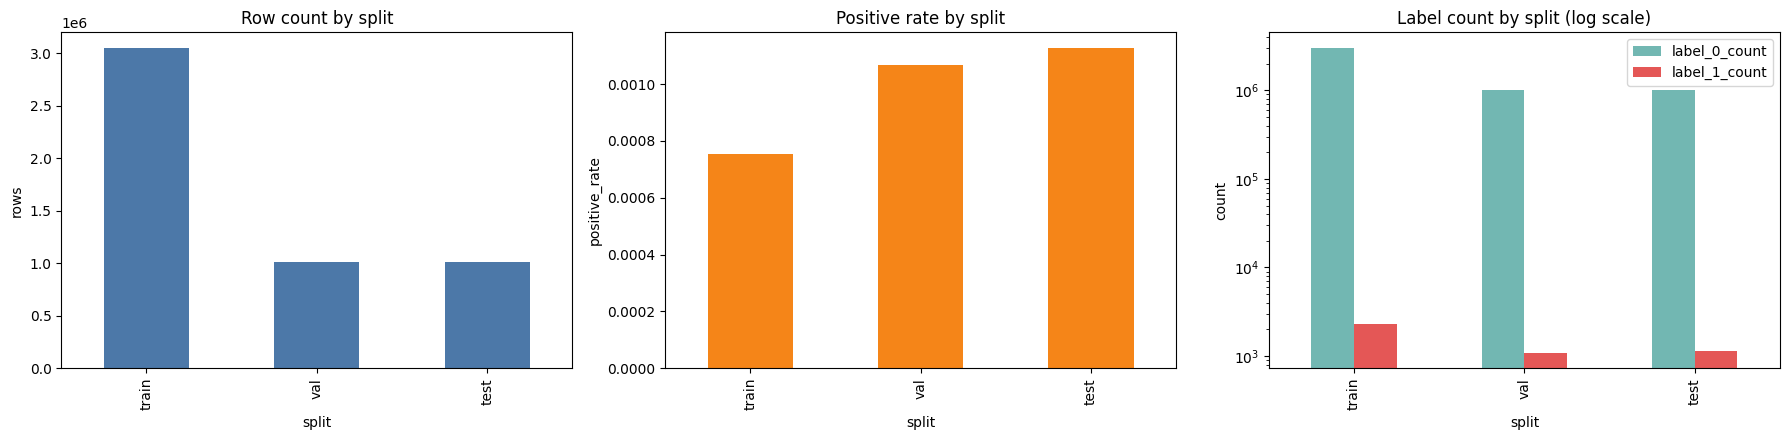

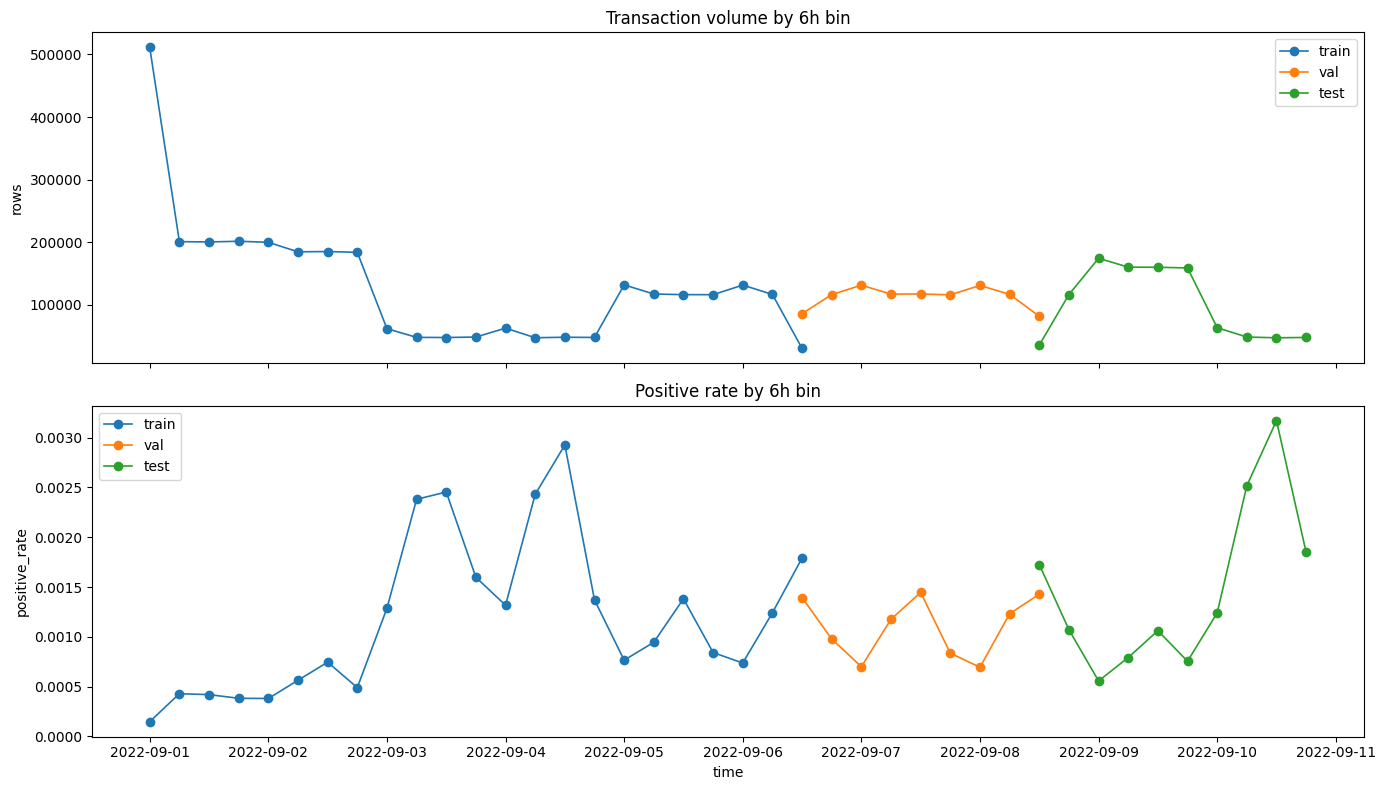

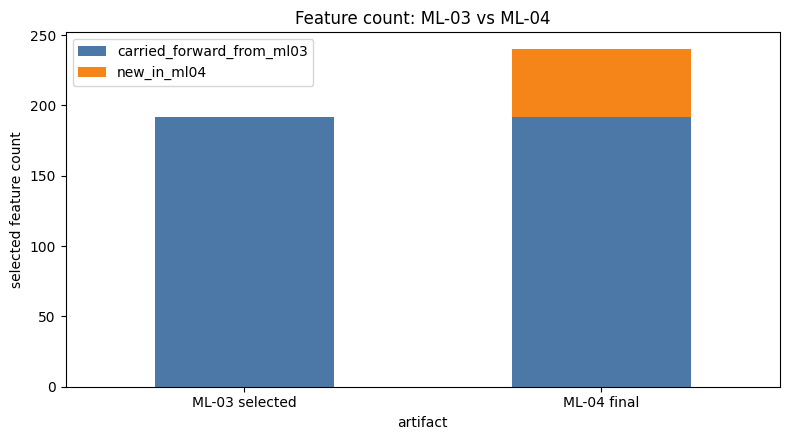

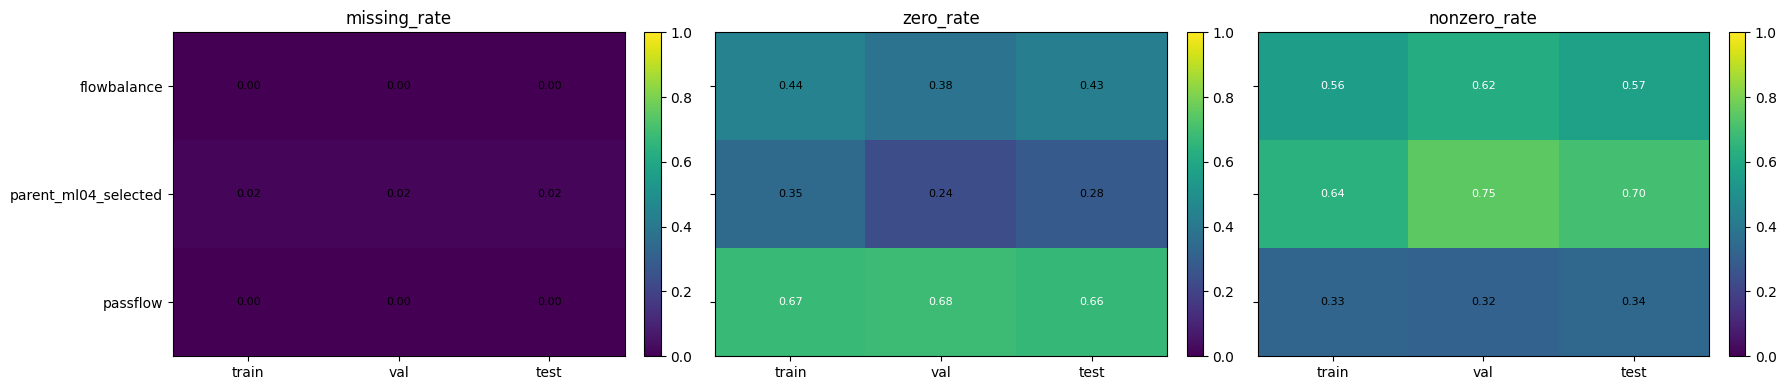

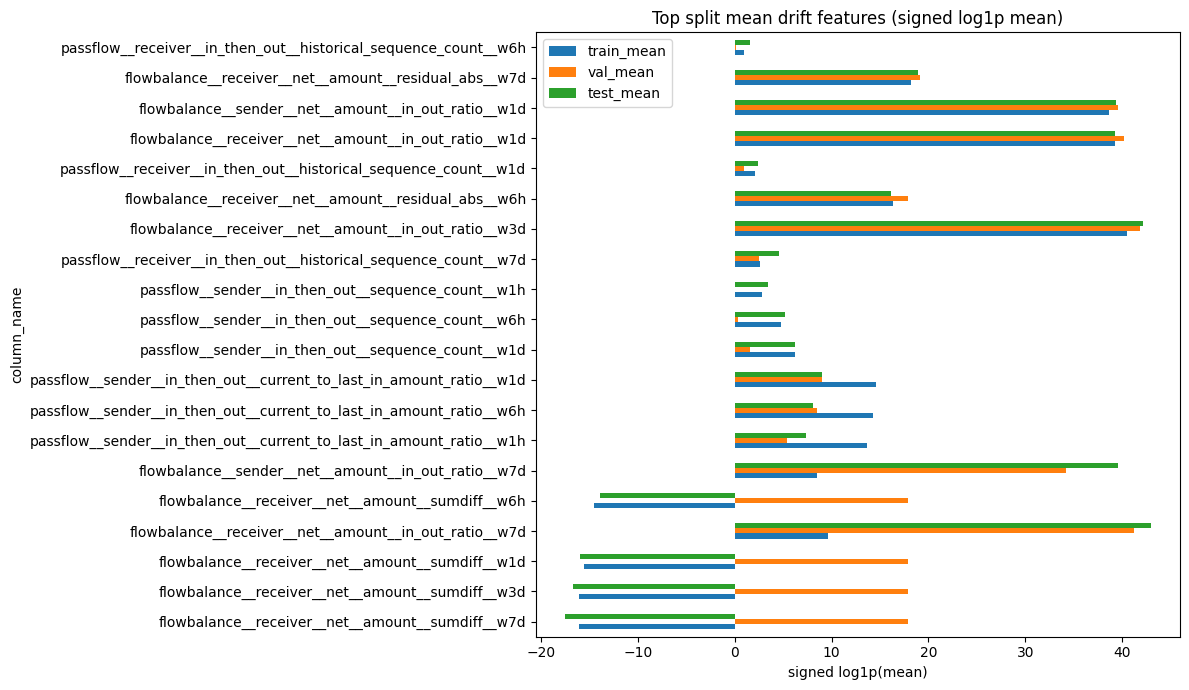

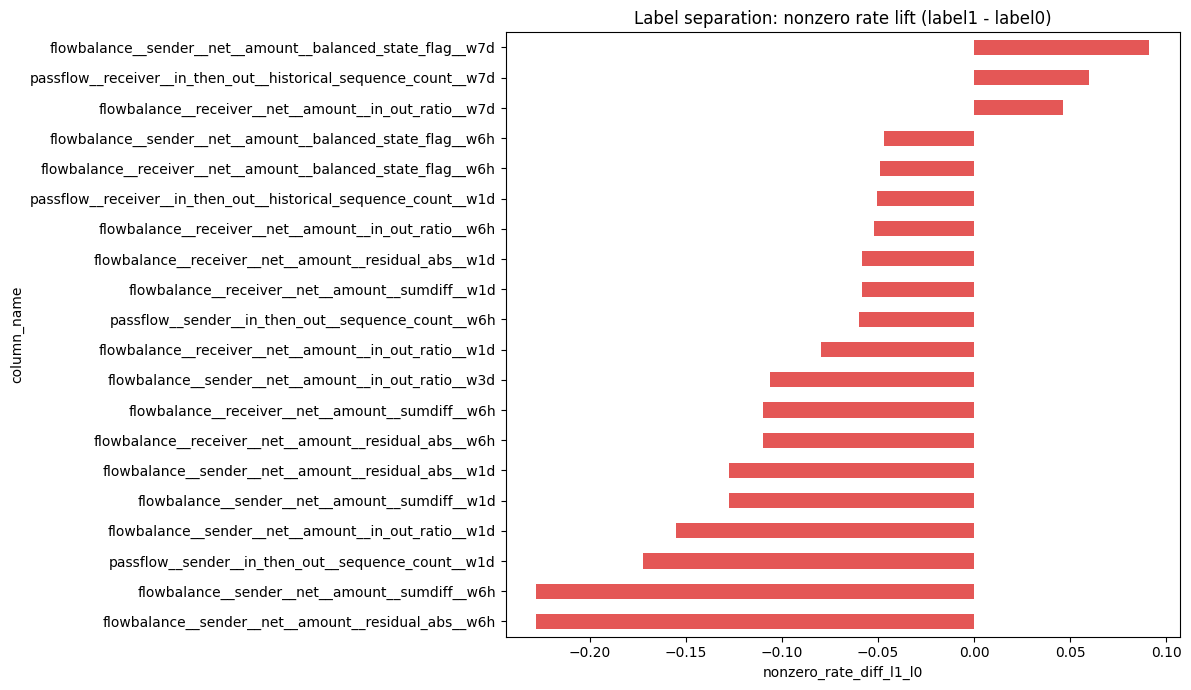

In [8]:
display(Markdown("## 8. Visual checks"))

# 8.1 split별 row count + positive rate bar, log-scale label count
split_plot_df = split_summary_exact_df.set_index("split").reindex(SPLIT_ORDER).dropna(how="all")
fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))
split_plot_df["rows"].plot(kind="bar", ax=axes[0], color="#4C78A8")
axes[0].set_title("Row count by split")
axes[0].set_xlabel("split")
axes[0].set_ylabel("rows")
split_plot_df["positive_rate"].plot(kind="bar", ax=axes[1], color="#F58518")
axes[1].set_title("Positive rate by split")
axes[1].set_xlabel("split")
axes[1].set_ylabel("positive_rate")
split_plot_df[["label_0_count", "label_1_count"]].plot(kind="bar", ax=axes[2], color=["#72B7B2", "#E45756"])
axes[2].set_title("Label count by split (log scale)")
axes[2].set_xlabel("split")
axes[2].set_ylabel("count")
axes[2].set_yscale("log")
plt.tight_layout()
plt.show()

# 8.2 시간대별 거래량/양성률 line plot
if not time_series_df.empty:
    fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
    for split in SPLIT_ORDER:
        split_time_df = time_series_df.loc[time_series_df["split"].eq(split)]
        if split_time_df.empty:
            continue
        axes[0].plot(split_time_df["time_bin"], split_time_df["rows"], marker="o", linewidth=1.2, label=split)
        axes[1].plot(split_time_df["time_bin"], split_time_df["positive_rate"], marker="o", linewidth=1.2, label=split)
    axes[0].set_title(f"Transaction volume by {TIME_BIN_FREQ} bin")
    axes[0].set_ylabel("rows")
    axes[0].legend()
    axes[1].set_title(f"Positive rate by {TIME_BIN_FREQ} bin")
    axes[1].set_ylabel("positive_rate")
    axes[1].set_xlabel("time")
    axes[1].legend()
    plt.tight_layout()
    plt.show()

# 8.3 ML-03 vs ML-04 feature count stacked bar
if contract_df is not None and not selected_contract_df.empty and "build_action" in selected_contract_df.columns:
    carry_forward_count = int(selected_contract_df["build_action"].astype("string").str.lower().eq("carry_forward").sum())
    build_count = int(selected_contract_df["build_action"].astype("string").str.lower().eq("build").sum())
    stage_count_df = pd.DataFrame(
        {
            "carried_forward_from_ml03": [carry_forward_count, carry_forward_count],
            "new_in_ml04": [0, build_count],
        },
        index=["ML-03 selected", "ML-04 final"],
    )
    ax = stage_count_df.plot(kind="bar", stacked=True, figsize=(8, 4.5), color=["#4C78A8", "#F58518"])
    ax.set_title("Feature count: ML-03 vs ML-04")
    ax.set_xlabel("artifact")
    ax.set_ylabel("selected feature count")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

# 8.4 feature group x split missing/zero/nonzero heatmap
if not group_split_quality_df.empty:
    metrics = ["missing_rate", "zero_rate", "nonzero_rate"]
    fig, axes = plt.subplots(1, 3, figsize=(18, max(4, len(groups) * 0.45)), sharey=True)
    for ax, metric in zip(axes, metrics):
        pivot = group_split_quality_df.pivot(index="feature_group", columns="split", values=metric).reindex(index=groups, columns=SPLIT_ORDER)
        im = ax.imshow(pivot.to_numpy(dtype=float), aspect="auto", cmap="viridis", vmin=0, vmax=1)
        ax.set_title(metric)
        ax.set_xticks(range(len(pivot.columns)))
        ax.set_xticklabels(pivot.columns)
        ax.set_yticks(range(len(pivot.index)))
        ax.set_yticklabels(pivot.index)
        for i in range(pivot.shape[0]):
            for j in range(pivot.shape[1]):
                value = pivot.iloc[i, j]
                if pd.notna(value):
                    ax.text(j, i, f"{value:.2f}", ha="center", va="center", color="white" if value > 0.5 else "black", fontsize=8)
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()

# 8.5 신규 피처 train/val/test mean drift top N bar
if not review_split_df.empty:
    drift_top = review_split_df.sort_values("max_abs_signed_log1p_mean_gap_vs_train", ascending=False).head(min(TOP_N, 20))
    plot_df = drift_top.set_index("column_name")[["train_mean", "val_mean", "test_mean"]].apply(lambda col: np.sign(col) * np.log1p(np.abs(col)), axis=0)
    ax = plot_df.plot(kind="barh", figsize=(12, max(5, len(drift_top) * 0.35)))
    ax.set_title("Top split mean drift features (signed log1p mean)")
    ax.set_xlabel("signed log1p(mean)")
    ax.set_ylabel("column_name")
    plt.tight_layout()
    plt.show()

# 8.6 label별 nonzero rate lift bar
if not review_label_df.empty:
    lift_top = review_label_df.reindex(review_label_df["nonzero_rate_diff_l1_l0"].abs().sort_values(ascending=False).index).head(min(TOP_N, 20))
    ax = lift_top.sort_values("nonzero_rate_diff_l1_l0").plot(
        x="column_name",
        y="nonzero_rate_diff_l1_l0",
        kind="barh",
        legend=False,
        figsize=(12, max(5, len(lift_top) * 0.35)),
        color="#E45756",
    )
    ax.set_title("Label separation: nonzero rate lift (label1 - label0)")
    ax.set_xlabel("nonzero_rate_diff_l1_l0")
    ax.set_ylabel("column_name")
    plt.tight_layout()
    plt.show()

# 8.7 신규 pair window 간 correlation heatmap
if not corr_df.empty:
    fig, ax = plt.subplots(figsize=(max(9, len(corr_df) * 0.32), max(8, len(corr_df) * 0.32)))
    im = ax.imshow(corr_df.to_numpy(), cmap="coolwarm", vmin=-1, vmax=1)
    ax.set_title("Pair-window feature correlation")
    ax.set_xticks(range(len(corr_df.columns)))
    ax.set_yticks(range(len(corr_df.index)))
    ax.set_xticklabels(corr_df.columns, rotation=90, fontsize=7)
    ax.set_yticklabels(corr_df.index, fontsize=7)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()


In [9]:
display(Markdown("## 9. Targeted pair feature label plots"))

def find_feature_by_suffix_or_contains(candidates: list[str], patterns: list[str]) -> Optional[str]:
    for pattern in patterns:
        for col in candidates:
            if pattern in col:
                return col
    return None

pair_plot_features = []
for patterns in [
    ["forward__is_new_pair"],
    ["forward__age_hours_since_first"],
    ["forward__tx_count__count__w3d"],
    ["forward__tx_count__count__w7d"],
]:
    matched = find_feature_by_suffix_or_contains(review_feature_columns, patterns)
    if matched is not None:
        pair_plot_features.append(matched)
pair_plot_features = list(dict.fromkeys(pair_plot_features))

if not pair_plot_features:
    display(Markdown("대상 pair feature를 찾지 못했습니다."))
else:
    plot_df = pq.read_table(target_path, columns=[label_col, *pair_plot_features]).to_pandas()
    plot_df[label_col] = pd.to_numeric(plot_df[label_col], errors="coerce").fillna(-1).astype("int8")
    for col in pair_plot_features:
        plot_df[col] = pd.to_numeric(plot_df[col], errors="coerce").replace([np.inf, -np.inf], np.nan)

    fig, axes = plt.subplots(len(pair_plot_features), 2, figsize=(14, max(4, len(pair_plot_features) * 3.2)))
    axes = np.atleast_2d(axes)
    for row_idx, col in enumerate(pair_plot_features):
        values_by_label = [plot_df.loc[plot_df[label_col].eq(label), col].dropna().to_numpy() for label in LABEL_ORDER]
        transformed_by_label = [signed_log1p_array(values) for values in values_by_label]

        axes[row_idx, 0].boxplot(transformed_by_label, labels=[str(label) for label in LABEL_ORDER], showfliers=False)
        axes[row_idx, 0].set_title(f"{col} by label (signed log1p box)")
        axes[row_idx, 0].set_xlabel(label_col)
        axes[row_idx, 0].set_ylabel("signed log1p(value)")

        axes[row_idx, 1].hist(
            transformed_by_label,
            bins=60,
            label=[f"label={label}" for label in LABEL_ORDER],
            alpha=0.65,
            log=True,
        )
        axes[row_idx, 1].set_title(f"{col} by label (signed log1p hist, log count)")
        axes[row_idx, 1].set_xlabel("signed log1p(value)")
        axes[row_idx, 1].set_ylabel("count")
        axes[row_idx, 1].legend()
    plt.tight_layout()
    plt.show()


## 9. Targeted pair feature label plots

대상 pair feature를 찾지 못했습니다.

In [10]:
display(Markdown("## 10. Review checklist"))

issues = []
if missing_feature_columns:
    issues.append({"severity": "error", "check": "feature_list_vs_parquet", "detail": f"{len(missing_feature_columns)} feature columns are absent from parquet"})
if forbidden_selected:
    issues.append({"severity": "error", "check": "forbidden_feature_patterns", "detail": f"Selected feature list includes forbidden columns: {forbidden_selected}"})
if contract_df is None:
    issues.append({"severity": "warning", "check": "contract", "detail": "No contract artifact was loaded"})
if encoding_manifest is None:
    issues.append({"severity": "info", "check": "encoding_manifest", "detail": "No encoding manifest was loaded"})
if feature_types is None:
    issues.append({"severity": "info", "check": "feature_types", "detail": "No feature_types artifact was loaded"})

if not feature_quality_df.empty:
    inf_rows = feature_quality_df[feature_quality_df["inf_count"].fillna(0) > 0]
    if len(inf_rows) > 0:
        issues.append({"severity": "error", "check": "feature_inf", "detail": f"{len(inf_rows)} review feature columns contain +/-inf"})
    high_missing = feature_quality_df[feature_quality_df["missing_rate"].fillna(0) >= 0.5]
    if len(high_missing) > 0:
        issues.append({"severity": "warning", "check": "feature_missing_rate", "detail": f"{len(high_missing)} review feature columns have missing_rate >= 0.5"})

if not split_summary_exact_df.empty:
    zero_positive_splits = split_summary_exact_df.loc[split_summary_exact_df["label_1_count"].fillna(0).eq(0), "split"].tolist()
    if zero_positive_splits:
        issues.append({"severity": "error", "check": "split_positive_label", "detail": f"No positive label rows in split(s): {zero_positive_splits}"})

issue_df = pd.DataFrame(issues) if issues else pd.DataFrame([{"severity": "ok", "check": "full_artifact_review", "detail": "No blocking issue detected by exact notebook checks"}])
display(issue_df)

display(Markdown("### Suggested manual checks"))
display(
    pd.DataFrame(
        [
            {"check": "누수", "detail": "신규 feature의 leakage_policy 또는 생성 로직이 timestamp < current_timestamp 원칙을 지키는지 확인한다."},
            {"check": "승인", "detail": "ML 학습에는 fb_outputs 후보가 아니라 승인된 ml_inputs contract의 used_in_ml=True 컬럼만 사용한다."},
            {"check": "drift", "detail": "split drift가 큰 피처는 시간 누적 효과인지, 분할 경계 문제인지, 모델 안정성 리스크인지 구분한다."},
            {"check": "label separation", "detail": "label separation이 과도하게 큰 피처는 도메인상 자연스러운 신규성/반복성 신호인지 누수 의심 신호인지 별도 검토한다."},
        ]
    )
)


## 10. Review checklist

,severity,check,detail
0,ok,full_artifact_review,No blocking issue detected by exact notebook checks


### Suggested manual checks

,check,detail
0,누수,신규 feature의 leakage_policy 또는 생성 로직이 timestamp < current_timestamp 원칙을 지키는지 확인한다.
1,승인,ML 학습에는 fb_outputs 후보가 아니라 승인된 ml_inputs contract의 used_in_ml=True 컬럼만 사용한다.
2,drift,"split drift가 큰 피처는 시간 누적 효과인지, 분할 경계 문제인지, 모델 안정성 리스크인지 구분한다."
3,label separation,label separation이 과도하게 큰 피처는 도메인상 자연스러운 신규성/반복성 신호인지 누수 의심 신호인지 별도 검토한다.


## 11. ML readiness dashboard

아래 셀들은 기존 review 결과를 바탕으로 ML 학습 투입 전 최종 확인용 표와 그림을 추가한다.
기존 artifact를 수정하지 않고, 현재 노트북 메모리에 있는 summary와 필요한 경우 parquet batch scan만 사용한다.


In [11]:
READINESS_HIGH_MISSING_RATE = 0.50
READINESS_HIGH_ZERO_RATE = 0.995
DIST_PLOT_ROWS_PER_LABEL = 20_000
DIST_PLOT_FEATURE_LIMIT = 12
CORR_FEATURE_LIMIT = 40
CORR_TOP_N = 30

FORBIDDEN_REVIEW_PATTERNS = (
    "laundering",
    "is_laundering",
    "pattern",
    "typology",
    "attempt",
    "target",
    "label",
)
SUSPICIOUS_LEAKAGE_TEXT_PATTERNS = (
    "future",
    "full data",
    "whole data",
    "global",
    "all data",
    "test edge",
    "unknown",
    "todo",
    "tbd",
    "확인 필요",
    "미정",
    "전체 데이터",
    "미래",
)


def text_value(value: Any) -> str:
    if value is None or pd.isna(value):
        return ""
    return str(value)


def compact_status_table(df: pd.DataFrame) -> pd.DataFrame:
    if df.empty:
        return df
    order = {"ERROR": 0, "WARN": 1, "INFO": 2, "PASS": 3}
    return (
        df.assign(_order=df["status"].map(order).fillna(99))
        .sort_values(["_order", "check"])
        .drop(columns="_order")
        .reset_index(drop=True)
    )


def readiness_row(status: str, check: str, detail: str, action: str, bucket: str) -> dict[str, str]:
    return {"status": status, "bucket": bucket, "check": check, "detail": detail, "action": action}


def forbidden_name_hits(column_name: str) -> list[str]:
    normalized = normalize_name(column_name)
    hits = [pattern for pattern in FORBIDDEN_REVIEW_PATTERNS if pattern in normalized]
    if normalized in {"y", "target", "label"}:
        hits.append("exact_target_like_name")
    if normalized.endswith("_y") or normalized.endswith("_label") or normalized.endswith("_target"):
        hits.append("target_like_suffix")
    return sorted(set(hits))


def feature_metric_type(column_name: str) -> str:
    name = normalize_name(column_name)
    if "ratio" in name or "rate" in name or "pct" in name:
        return "ratio_or_rate"
    if "amount" in name or "sumdiff" in name or "residual" in name or "balance" in name or "net_flow" in name:
        return "amount_or_balance"
    if "flag" in name or name.startswith("is_") or "exists" in name:
        return "flag"
    if "count" in name or "degree" in name or "fan" in name or "unique" in name:
        return "count_or_degree"
    if "seconds" in name or "hours" in name or "time_since" in name or "age" in name or "recency" in name:
        return "time_gap"
    return "other"


def feature_stage_family(row: pd.Series) -> str:
    column_name = text_value(row.get("column_name"))
    name = normalize_name(column_name)
    feature_group = normalize_name(text_value(row.get("feature_group")))
    operation = normalize_name(text_value(row.get("operation")))
    spec_name = normalize_name(text_value(row.get("feature_spec_name")))
    stage_text = normalize_name(text_value(row.get("stage")))
    joined = " ".join([name, feature_group, operation, spec_name, stage_text])

    if "flowbalance" in joined or "flow_balance" in joined:
        return "ML-05 Stage 4 flow-balance"
    if "passflow" in joined or "pass_through" in joined or "passflow_window" in joined:
        return "ML-05 Stage 4 pass-through"
    if "gatherscatter" in joined or "gather_scatter" in joined or "gather" in joined or "scatter" in joined:
        return "Stage 5 gather-scatter optional"
    if "twohop" in joined or "two_hop" in joined or "2hop" in joined or "temporal_path" in joined:
        return "Stage 5 2-hop optional"
    if "cycle" in joined or "triad" in joined:
        return "Stage 5 cycle optional"
    if "bipartite" in joined or "component_density" in joined:
        return "Stage 5 bipartite optional"
    if "topology" in joined or "pagerank" in joined or "centrality" in joined:
        return "Stage 5 train-only topology optional"
    if "pair" in joined or "reverse" in joined or "self_loop" in joined:
        return "Stage 3 pair/reverse"
    if "fanin" in joined or "fanout" in joined or "fan_in" in joined or "fan_out" in joined:
        return "Stage 2 fan-in/fan-out"
    if "timehist" in joined or "recency" in joined or "time_history" in joined:
        return "Stage 0 time history"
    if "account" in joined or "acct" in joined:
        return "Stage 1 account stats"
    if "parent" in feature_group or "carry_forward" in joined:
        return "carried-forward selected"
    return "other selected feature"


def build_feature_review_catalog() -> pd.DataFrame:
    base = pd.DataFrame({"column_name": feature_columns_in_parquet})
    contract_cols = [
        "column_name",
        "used_in_ml",
        "feature_group",
        "feature_spec_name",
        "build_action",
        "encoding",
        "leakage_risk",
        "review_status",
        "selection_note",
    ]
    if contract_df is not None and "column_name" in contract_df.columns:
        available_cols = [col for col in contract_cols if col in contract_df.columns]
        contract_unique = contract_df[available_cols].drop_duplicates("column_name")
        base = base.merge(contract_unique, on="column_name", how="left")
    base["stage_family"] = base.apply(feature_stage_family, axis=1)
    base["metric_type"] = base["column_name"].map(feature_metric_type)
    base["forbidden_name_hits"] = base["column_name"].map(forbidden_name_hits)
    base["has_forbidden_name_hit"] = base["forbidden_name_hits"].map(bool)
    if "build_action" not in base.columns:
        base["build_action"] = "unknown"
    base["build_action"] = base["build_action"].astype("string").fillna("unknown")
    return base


def add_feature_context(df: pd.DataFrame) -> pd.DataFrame:
    if df.empty or "column_name" not in df.columns:
        return df
    context_cols = ["column_name", "stage_family", "metric_type", "feature_group", "build_action"]
    available = [col for col in context_cols if col in feature_review_catalog_df.columns]
    return df.merge(feature_review_catalog_df[available].drop_duplicates("column_name"), on="column_name", how="left")


def top_correlation_pairs(corr_matrix: pd.DataFrame, *, top_n: int = CORR_TOP_N) -> pd.DataFrame:
    rows = []
    if corr_matrix.empty:
        return pd.DataFrame(columns=["feature_a", "feature_b", "corr", "abs_corr"])
    columns = corr_matrix.columns.tolist()
    for i, feature_a in enumerate(columns):
        for j in range(i + 1, len(columns)):
            feature_b = columns[j]
            corr_value = corr_matrix.iat[i, j]
            if np.isfinite(corr_value):
                rows.append(
                    {
                        "feature_a": feature_a,
                        "feature_b": feature_b,
                        "corr": float(corr_value),
                        "abs_corr": float(abs(corr_value)),
                    }
                )
    if not rows:
        return pd.DataFrame(columns=["feature_a", "feature_b", "corr", "abs_corr"])
    return pd.DataFrame(rows).sort_values("abs_corr", ascending=False).head(top_n).reset_index(drop=True)


def compute_streaming_corr(path: Path, columns: list[str]) -> pd.DataFrame:
    use_columns = [col for col in dict.fromkeys(columns) if col in schema_columns]
    if len(use_columns) < 2:
        return pd.DataFrame()
    n_rows = 0
    values_sum = np.zeros(len(use_columns), dtype=np.float64)
    cross_sum = np.zeros((len(use_columns), len(use_columns)), dtype=np.float64)
    local_pf = pq.ParquetFile(path)
    for batch in local_pf.iter_batches(batch_size=BATCH_SIZE, columns=use_columns):
        df = batch.to_pandas()
        matrix = (
            df[use_columns]
            .apply(pd.to_numeric, errors="coerce")
            .replace([np.inf, -np.inf], np.nan)
            .fillna(0.0)
            .to_numpy(dtype=np.float64)
        )
        n_rows += matrix.shape[0]
        values_sum += matrix.sum(axis=0)
        cross_sum += matrix.T @ matrix
    if n_rows <= 1:
        return pd.DataFrame()
    means = values_sum / n_rows
    cov = cross_sum / n_rows - np.outer(means, means)
    std = np.sqrt(np.clip(np.diag(cov), 0, None))
    denom = np.outer(std, std)
    with np.errstate(divide="ignore", invalid="ignore"):
        corr = np.divide(cov, denom, out=np.zeros_like(cov), where=denom > 0)
    return pd.DataFrame(np.clip(corr, -1, 1), index=use_columns, columns=use_columns)


def read_label_stratified_plot_sample(
    path: Path,
    feature_cols: list[str],
    label_column: str,
    *,
    rows_per_label: int = DIST_PLOT_ROWS_PER_LABEL,
) -> pd.DataFrame:
    use_columns = [col for col in dict.fromkeys([label_column, *feature_cols]) if col in schema_columns]
    if label_column not in use_columns or len(use_columns) <= 1:
        return pd.DataFrame(columns=use_columns)
    pieces = []
    counts = {label: 0 for label in LABEL_ORDER}
    local_pf = pq.ParquetFile(path)
    for batch in local_pf.iter_batches(batch_size=BATCH_SIZE, columns=use_columns):
        df = batch.to_pandas()
        labels = pd.to_numeric(df[label_column], errors="coerce").fillna(-1).astype("int8")
        for label in LABEL_ORDER:
            remaining = rows_per_label - counts[label]
            if remaining <= 0:
                continue
            part = df.loc[labels.eq(label)].head(remaining)
            if not part.empty:
                pieces.append(part)
                counts[label] += len(part)
        if all(counts[label] >= rows_per_label for label in LABEL_ORDER):
            break
    if not pieces:
        return pd.DataFrame(columns=use_columns)
    return pd.concat(pieces, ignore_index=True)


def scan_split_time_ranges(path: Path, split_column: str, time_column: str) -> tuple[pd.DataFrame, pd.DataFrame]:
    states: dict[str, dict[str, Any]] = {}
    local_pf = pq.ParquetFile(path)
    for batch in local_pf.iter_batches(batch_size=BATCH_SIZE, columns=[split_column, time_column]):
        df = batch.to_pandas()
        split_values = df[split_column].astype("string").fillna("<NA>")
        time_values = pd.to_datetime(df[time_column], errors="coerce")
        frame = pd.DataFrame({"split": split_values, "timestamp": time_values}).dropna(subset=["timestamp"])
        if frame.empty:
            continue
        grouped = frame.groupby("split", observed=True)["timestamp"].agg(["min", "max", "count"])
        for split, row in grouped.iterrows():
            split_name = str(split)
            current = states.setdefault(split_name, {"min": None, "max": None, "rows_with_timestamp": 0})
            min_ts = pd.Timestamp(row["min"])
            max_ts = pd.Timestamp(row["max"])
            current["min"] = min_ts if current["min"] is None else min(current["min"], min_ts)
            current["max"] = max_ts if current["max"] is None else max(current["max"], max_ts)
            current["rows_with_timestamp"] += int(row["count"])
    range_rows = [
        {
            "split": split,
            "min_timestamp": state["min"],
            "max_timestamp": state["max"],
            "rows_with_timestamp": state["rows_with_timestamp"],
        }
        for split, state in states.items()
    ]
    range_df = pd.DataFrame(range_rows)
    if not range_df.empty:
        range_df["split"] = pd.Categorical(range_df["split"], categories=SPLIT_ORDER, ordered=True)
        range_df = range_df.sort_values("split").reset_index(drop=True)

    boundary_rows = []
    range_by_split = {str(row.split): row for row in range_df.itertuples(index=False)} if not range_df.empty else {}
    for left, right in zip(SPLIT_ORDER, SPLIT_ORDER[1:]):
        if left not in range_by_split or right not in range_by_split:
            boundary_rows.append(
                {
                    "boundary": f"{left}->{right}",
                    "status": "WARN",
                    "detail": "one or both splits are missing timestamp range information",
                }
            )
            continue
        left_max = pd.Timestamp(range_by_split[left].max_timestamp)
        right_min = pd.Timestamp(range_by_split[right].min_timestamp)
        if left_max < right_min:
            status = "PASS"
            detail = "strictly ordered; no range overlap"
        elif left_max == right_min:
            status = "WARN"
            detail = "adjacent splits touch at the same timestamp; same-timestamp leakage policy should be checked"
        else:
            status = "ERROR"
            detail = "timestamp ranges overlap"
        boundary_rows.append(
            {
                "boundary": f"{left}->{right}",
                "status": status,
                "left_max_timestamp": left_max,
                "right_min_timestamp": right_min,
                "detail": detail,
            }
        )
    return range_df, pd.DataFrame(boundary_rows)


feature_review_catalog_df = build_feature_review_catalog()

display(Markdown("### Current target and ML-05 path helper"))
ml05_prefix = f"ml_05__{RUN_ID}"
ml05_expected_path = LOCAL_REPO_ROOT / "ml" / "ml-05" / "fb_outputs" / RUN_ID / f"{ml05_prefix}_Xy_all.parquet"
display(
    pd.DataFrame(
        [
            {
                "item": "current_target",
                "value": str(target_path),
                "exists": target_path.exists(),
            },
            {
                "item": "ml05_expected_target_if_same_run_id",
                "value": str(ml05_expected_path),
                "exists": ml05_expected_path.exists(),
            },
            {
                "item": "how_to_switch_to_ml05",
                "value": "set EXPORT_EXPERIMENT_ID='ml_05' and TARGET_PARQUET_PATH to the ml/ml-05/fb_outputs/<RUN_ID>/<prefix>_Xy_all.parquet path",
                "exists": None,
            },
        ]
    )
)

display(Markdown("### Selected feature interpretation catalog"))
display(feature_review_catalog_df.head(TOP_N))


### Current target and ML-05 path helper

,item,value,exists
0,current_target,/mnt/d/AML_git/Graph_AML/ml/ml-05/fb_outputs/r00/ml_05__r00_Xy_all.parquet,True
1,ml05_expected_target_if_same_run_id,/mnt/d/AML_git/Graph_AML/ml/ml-05/fb_outputs/r00/ml_05__r00_Xy_all.parquet,True
2,how_to_switch_to_ml05,set EXPORT_EXPERIMENT_ID='ml_05' and TARGET_PARQUET_PATH to the ml/ml-05/fb_outputs/<RUN_ID>/<prefix>_Xy_all.parquet path,None


### Selected feature interpretation catalog

,column_name,used_in_ml,feature_group,feature_spec_name,build_action,encoding,leakage_risk,review_status,selection_note,stage_family,metric_type,forbidden_name_hits,has_forbidden_name_hit
0,amount__current__value,True,parent_ml04_selected,NaN,carry_forward,passthrough,inherited_from_ml04_parent_contract,approved,carried forward from ML-04 parent selected ML input contract,carried-forward selected,amount_or_balance,[],False
1,amount__current__log1p,True,parent_ml04_selected,NaN,carry_forward,passthrough,inherited_from_ml04_parent_contract,approved,carried forward from ML-04 parent selected ML input contract,carried-forward selected,amount_or_balance,[],False
2,amount_received__current__value,True,parent_ml04_selected,NaN,carry_forward,passthrough,inherited_from_ml04_parent_contract,approved,carried forward from ML-04 parent selected ML input contract,carried-forward selected,amount_or_balance,[],False
3,amount_received__current__log1p,True,parent_ml04_selected,NaN,carry_forward,passthrough,inherited_from_ml04_parent_contract,approved,carried forward from ML-04 parent selected ML input contract,carried-forward selected,amount_or_balance,[],False
4,amount__paid_recv_ratio,True,parent_ml04_selected,NaN,carry_forward,passthrough,inherited_from_ml04_parent_contract,approved,carried forward from ML-04 parent selected ML input contract,carried-forward selected,ratio_or_rate,[],False
5,timehist__sender__out__tx_count__count__w1h,True,parent_ml04_selected,NaN,carry_forward,passthrough,inherited_from_ml04_parent_contract,approved,carried forward from ML-04 parent selected ML input contract,Stage 0 time history,count_or_degree,[],False
6,timehist__sender__out__amount__sum__w1h,True,parent_ml04_selected,NaN,carry_forward,passthrough,inherited_from_ml04_parent_contract,approved,carried forward from ML-04 parent selected ML input contract,Stage 0 time history,amount_or_balance,[],False
7,timehist__sender__out__amount__mean__w1h,True,parent_ml04_selected,NaN,carry_forward,passthrough,inherited_from_ml04_parent_contract,approved,carried forward from ML-04 parent selected ML input contract,Stage 0 time history,amount_or_balance,[],False
8,timehist__sender__out__amount__std__w1h,True,parent_ml04_selected,NaN,carry_forward,passthrough,inherited_from_ml04_parent_contract,approved,carried forward from ML-04 parent selected ML input contract,Stage 0 time history,amount_or_balance,[],False
9,timehist__sender__out__amount__max__w1h,True,parent_ml04_selected,NaN,carry_forward,passthrough,inherited_from_ml04_parent_contract,approved,carried forward from ML-04 parent selected ML input contract,Stage 0 time history,amount_or_balance,[],False


## 12. Beginner readiness summary

,status,bucket,check,detail,action
0,PASS,통과,binary_label_values,unexpected_label_values=[],label은 0/1 이진값이어야 한다.
1,PASS,통과,feature_inf_values,features_with_inf=0,+/-inf는 XGBoost 입력 전 반드시 원인 확인 또는 변환 정책이 필요하다.
2,PASS,통과,feature_list_vs_parquet,missing_feature_columns=0,누락 feature가 있으면 contract와 parquet 생성 run이 같은지 확인한다.
3,PASS,통과,forbidden_or_target_like_feature_names,"forbidden_selected=0, target_like_name_hits=0","label, laundering, pattern, typology, attempt 계열 이름은 모델 입력에서 제외한다."
4,PASS,통과,high_missing_feature_rate,features_missing_rate_ge_0.5=0,고결측 피처는 결측이 도메인 신호인지 생성 실패인지 구분한다.
5,PASS,통과,high_zero_feature_rate,features_zero_rate_ge_0.995=0,거의 전부 0인 피처는 희소 신호인지 불필요 후보인지 확인한다.
6,PASS,통과,near_zero_variance_features,near_zero_variance_features=0,near-zero variance 피처는 모델 기여보다 노이즈/비용이 큰지 확인한다.
7,PASS,통과,positive_label_exists_by_split,zero_positive_splits=[],양성 label이 없는 split은 threshold/평가가 불가능하므로 split 또는 샘플링을 확인한다.
8,PASS,통과,required_control_columns,"label=label, split=split, timestamp=timestamp",ERROR이면 parquet schema 또는 입력 파일을 먼저 확인한다.
9,PASS,통과,split_balance_sanity,"empty_splits=[], extreme_split_ratios=[]","시간순 split이므로 정확한 60/20/20 row 비율은 아니어도 되지만, 극단적 쏠림은 확인한다."


### Readiness bucket counts

,bucket,status,checks
0,통과,PASS,10


### Split and label balance for non-technical review

,split,rows,label_0_count,label_1_count,positive_rate,row_share,class_imbalance_ratio_label0_over_label1
0,test,1015418,1014275,1143,0.001126,0.199994,887.379703
1,train,3046186,3043890,2296,0.000754,0.599969,1325.736063
2,val,1015633,1014550,1083,0.001066,0.200037,936.795937


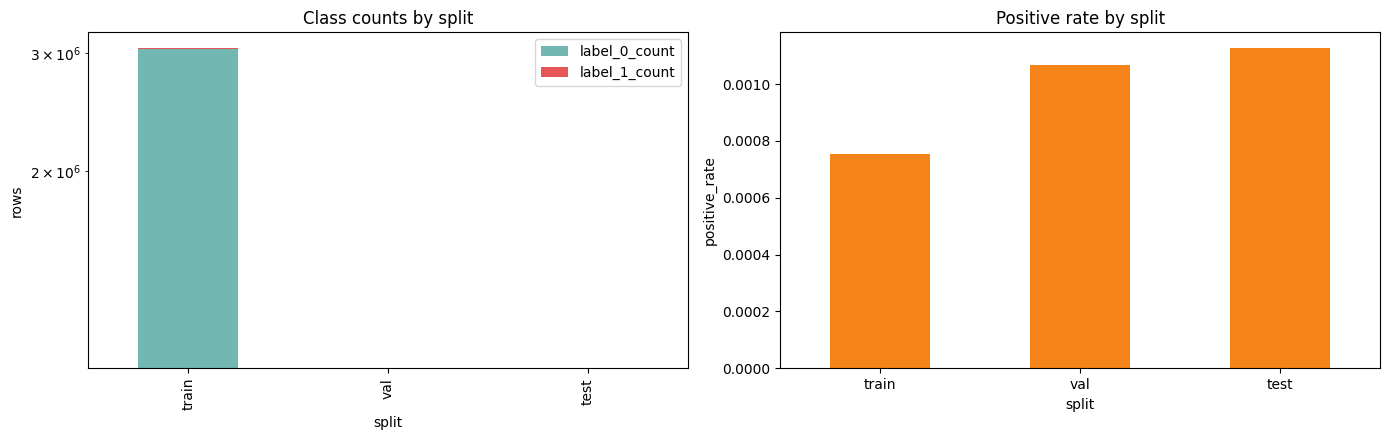

In [12]:
display(Markdown("## 12. Beginner readiness summary"))

readiness_rows = []

required_status = "PASS" if label_col and split_col and time_col else "ERROR"
readiness_rows.append(
    readiness_row(
        required_status,
        "required_control_columns",
        f"label={label_col}, split={split_col}, timestamp={time_col}",
        "ERROR이면 parquet schema 또는 입력 파일을 먼저 확인한다.",
        "바로 확인할 문제" if required_status == "ERROR" else "통과",
    )
)

readiness_rows.append(
    readiness_row(
        "ERROR" if missing_feature_columns else "PASS",
        "feature_list_vs_parquet",
        f"missing_feature_columns={len(missing_feature_columns)}",
        "누락 feature가 있으면 contract와 parquet 생성 run이 같은지 확인한다.",
        "바로 확인할 문제" if missing_feature_columns else "통과",
    )
)

forbidden_review_df = feature_review_catalog_df.loc[feature_review_catalog_df["has_forbidden_name_hit"]].copy()
readiness_rows.append(
    readiness_row(
        "ERROR" if not forbidden_review_df.empty or forbidden_selected else "PASS",
        "forbidden_or_target_like_feature_names",
        f"forbidden_selected={len(forbidden_selected)}, target_like_name_hits={len(forbidden_review_df)}",
        "label, laundering, pattern, typology, attempt 계열 이름은 모델 입력에서 제외한다.",
        "바로 확인할 문제" if not forbidden_review_df.empty or forbidden_selected else "통과",
    )
)

unexpected_label_values = sorted(set(label_counter.keys()) - set(LABEL_ORDER)) if label_counter else []
readiness_rows.append(
    readiness_row(
        "ERROR" if unexpected_label_values else "PASS",
        "binary_label_values",
        f"unexpected_label_values={unexpected_label_values}",
        "label은 0/1 이진값이어야 한다.",
        "바로 확인할 문제" if unexpected_label_values else "통과",
    )
)

if not split_summary_exact_df.empty:
    zero_positive_splits = split_summary_exact_df.loc[split_summary_exact_df["label_1_count"].fillna(0).eq(0), "split"].astype(str).tolist()
    empty_splits = split_summary_exact_df.loc[split_summary_exact_df["rows"].fillna(0).eq(0), "split"].astype(str).tolist()
    split_ratios = split_summary_exact_df.set_index("split")["rows"] / split_summary_exact_df["rows"].sum()
    extreme_split_names = split_ratios.loc[(split_ratios < 0.05) | (split_ratios > 0.90)].index.astype(str).tolist()
else:
    zero_positive_splits = []
    empty_splits = SPLIT_ORDER
    extreme_split_names = []

readiness_rows.append(
    readiness_row(
        "ERROR" if zero_positive_splits else "PASS",
        "positive_label_exists_by_split",
        f"zero_positive_splits={zero_positive_splits}",
        "양성 label이 없는 split은 threshold/평가가 불가능하므로 split 또는 샘플링을 확인한다.",
        "바로 확인할 문제" if zero_positive_splits else "통과",
    )
)
readiness_rows.append(
    readiness_row(
        "ERROR" if empty_splits else "WARN" if extreme_split_names else "PASS",
        "split_balance_sanity",
        f"empty_splits={empty_splits}, extreme_split_ratios={extreme_split_names}",
        "시간순 split이므로 정확한 60/20/20 row 비율은 아니어도 되지만, 극단적 쏠림은 확인한다.",
        "바로 확인할 문제" if empty_splits else "사람이 확인할 문제" if extreme_split_names else "통과",
    )
)

if not feature_quality_df.empty:
    inf_feature_count = int((feature_quality_df["inf_count"].fillna(0) > 0).sum())
    high_missing_count = int((feature_quality_df["missing_rate"].fillna(0) >= READINESS_HIGH_MISSING_RATE).sum())
    high_zero_count = int((feature_quality_df["zero_rate"].fillna(0) >= READINESS_HIGH_ZERO_RATE).sum())
else:
    inf_feature_count = 0
    high_missing_count = 0
    high_zero_count = 0

near_zero_count = 0
if feature_info_df is not None and "near_zero_variance" in feature_info_df.columns:
    near_zero_series = feature_info_df["near_zero_variance"].map(normalize_bool)
    near_zero_count = int(near_zero_series.sum())

readiness_rows.append(
    readiness_row(
        "ERROR" if inf_feature_count else "PASS",
        "feature_inf_values",
        f"features_with_inf={inf_feature_count}",
        "+/-inf는 XGBoost 입력 전 반드시 원인 확인 또는 변환 정책이 필요하다.",
        "바로 확인할 문제" if inf_feature_count else "통과",
    )
)
readiness_rows.append(
    readiness_row(
        "WARN" if high_missing_count else "PASS",
        "high_missing_feature_rate",
        f"features_missing_rate_ge_{READINESS_HIGH_MISSING_RATE}={high_missing_count}",
        "고결측 피처는 결측이 도메인 신호인지 생성 실패인지 구분한다.",
        "사람이 확인할 문제" if high_missing_count else "통과",
    )
)
readiness_rows.append(
    readiness_row(
        "WARN" if high_zero_count else "PASS",
        "high_zero_feature_rate",
        f"features_zero_rate_ge_{READINESS_HIGH_ZERO_RATE}={high_zero_count}",
        "거의 전부 0인 피처는 희소 신호인지 불필요 후보인지 확인한다.",
        "사람이 확인할 문제" if high_zero_count else "통과",
    )
)
readiness_rows.append(
    readiness_row(
        "WARN" if near_zero_count else "PASS",
        "near_zero_variance_features",
        f"near_zero_variance_features={near_zero_count}",
        "near-zero variance 피처는 모델 기여보다 노이즈/비용이 큰지 확인한다.",
        "사람이 확인할 문제" if near_zero_count else "통과",
    )
)

readiness_df = compact_status_table(pd.DataFrame(readiness_rows))
display(readiness_df)

display(Markdown("### Readiness bucket counts"))
readiness_bucket_df = (
    readiness_df.groupby(["bucket", "status"], dropna=False)
    .size()
    .reset_index(name="checks")
    .sort_values(["bucket", "status"])
)
display(readiness_bucket_df)

display(Markdown("### Split and label balance for non-technical review"))
split_beginner_df = split_summary_exact_df.copy()
if not split_beginner_df.empty:
    split_beginner_df["row_share"] = split_beginner_df["rows"] / split_beginner_df["rows"].sum()
    split_beginner_df["class_imbalance_ratio_label0_over_label1"] = split_beginner_df["label_0_count"] / split_beginner_df["label_1_count"].replace(0, np.nan)
display(split_beginner_df)

if not split_beginner_df.empty:
    plot_df = split_beginner_df.set_index("split").reindex(SPLIT_ORDER).dropna(how="all")
    fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
    plot_df[["label_0_count", "label_1_count"]].plot(kind="bar", stacked=True, ax=axes[0], color=["#72B7B2", "#E45756"])
    axes[0].set_title("Class counts by split")
    axes[0].set_xlabel("split")
    axes[0].set_ylabel("rows")
    axes[0].set_yscale("log")
    plot_df["positive_rate"].plot(kind="bar", ax=axes[1], color="#F58518")
    axes[1].set_title("Positive rate by split")
    axes[1].set_xlabel("split")
    axes[1].set_ylabel("positive_rate")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()


## 13. Stage-aware feature interpretation visuals

### Selected feature count by interpreted stage/family

,stage_family,build_action,feature_count
0,ML-05 Stage 4 flow-balance,build,32
1,ML-05 Stage 4 pass-through,build,16
2,Stage 0 time history,carry_forward,60
3,Stage 1 account stats,carry_forward,28
4,Stage 2 fan-in/fan-out,carry_forward,40
5,Stage 3 pair/reverse,carry_forward,46
6,carried-forward selected,carry_forward,18


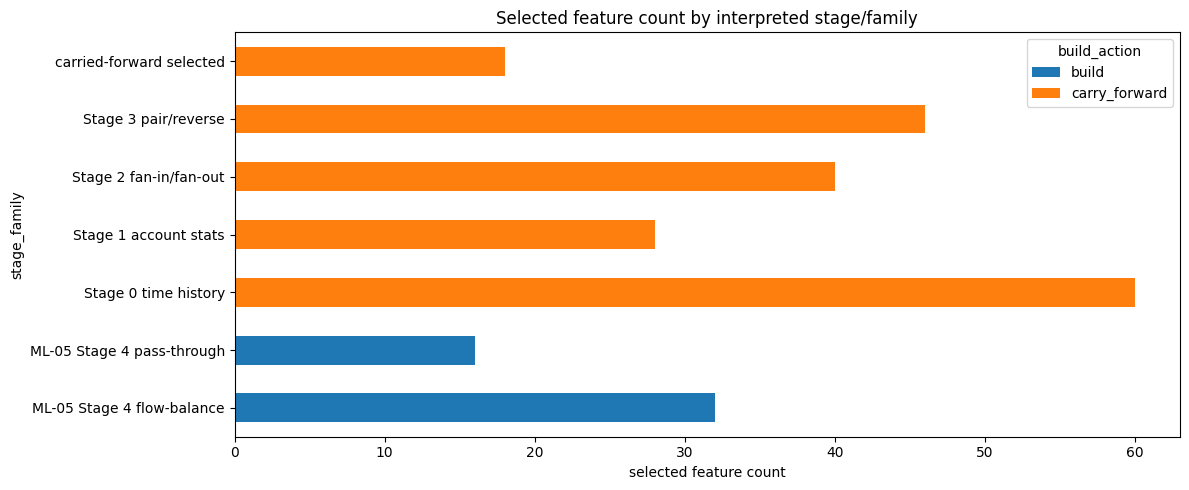

### Review priority with stage/family context

,column_name,missing_rate,inf_count,zero_rate,nonzero_rate,train_mean,train_nonzero_rate,train_zero_rate,train_missing_rate,val_mean,val_nonzero_rate,val_zero_rate,val_missing_rate,test_mean,test_nonzero_rate,test_zero_rate,test_missing_rate,val_train_mean_ratio,test_train_mean_ratio,max_abs_signed_log1p_mean_gap_vs_train,max_nonzero_rate_gap,mean_label0,mean_label1,mean_ratio_label1_over_label0,std_mean_diff,nonzero_rate_label0,nonzero_rate_label1,nonzero_rate_diff_l1_l0,review_priority_score,stage_family,metric_type,feature_group,build_action
0,flowbalance__receiver__net__amount__sumdiff__w7d,0.0,0,0.117369,0.882631,-9.799893e+06,0.810453,0.189547,0.0,6.143907e+07,0.997994,0.002006,0.0,-3.906684e+07,0.983769,0.016231,0.0,-6.269362e+00,3.986456e+00,34.031439,0.187541,-1.400368e+06,-4.036070e+06,2.882149,-0.000609,0.882618,0.896727,0.014109,34.351066,ML-05 Stage 4 flow-balance,amount_or_balance,flowbalance,build
1,flowbalance__receiver__net__amount__sumdiff__w3d,0.0,0,0.127285,0.872715,-9.414580e+06,0.804202,0.195798,0.0,5.697137e+07,0.994700,0.005300,0.0,-1.798523e+07,0.956242,0.043758,0.0,-6.051398e+00,1.910359e+00,33.915830,0.190498,2.154301e+06,-1.599439e+06,-0.742440,-0.001151,0.872739,0.846528,-0.026211,34.260974,ML-05 Stage 4 flow-balance,amount_or_balance,flowbalance,build
2,flowbalance__receiver__net__amount__in_out_ratio__w7d,0.0,0,0.245378,0.754622,1.534316e+04,0.773007,0.226993,0.0,8.513499e+17,0.877184,0.122816,0.0,4.564495e+18,0.576882,0.423118,0.0,5.548727e+13,2.974939e+14,33.326349,0.300302,1.082977e+18,1.304082e+18,1.204164,0.001039,0.754581,0.800973,0.046392,33.919460,ML-05 Stage 4 flow-balance,ratio_or_rate,flowbalance,build
3,flowbalance__receiver__net__amount__sumdiff__w1d,0.0,0,0.202615,0.797385,-5.689383e+06,0.742965,0.257035,0.0,5.646283e+07,0.895281,0.104719,0.0,-8.796167e+06,0.862725,0.137275,0.0,-9.924245e+00,1.546067e+00,33.403206,0.152316,6.124570e+06,3.231210e+06,0.527582,-0.001056,0.797437,0.739054,-0.058384,33.817576,ML-05 Stage 4 flow-balance,amount_or_balance,flowbalance,build
4,flowbalance__receiver__net__amount__sumdiff__w6h,0.0,0,0.414824,0.585176,-2.028877e+06,0.554725,0.445275,0.0,5.712810e+07,0.642039,0.357961,0.0,-1.050229e+06,0.619654,0.380346,0.0,-2.815750e+01,5.176403e-01,32.383800,0.087314,1.000955e+07,-2.537810e+05,-0.025354,-0.004092,0.585274,0.475674,-0.109599,32.999630,ML-05 Stage 4 flow-balance,amount_or_balance,flowbalance,build
5,flowbalance__sender__net__amount__in_out_ratio__w7d,0.0,0,0.177489,0.822511,4.671111e+03,0.788894,0.211106,0.0,7.198986e+14,0.963111,0.036889,0.0,1.623095e+17,0.782732,0.217268,0.0,1.541172e+11,3.474751e+13,31.178915,0.180379,3.261472e+16,2.165437e+16,0.663945,-0.000394,0.822502,0.832817,0.010315,31.547492,ML-05 Stage 4 flow-balance,ratio_or_rate,flowbalance,build
6,passflow__sender__in_then_out__current_to_last_in_amount_ratio__w1h,0.0,0,0.903100,0.096900,8.317750e+05,0.104571,0.895429,0.0,2.172058e+02,0.059354,0.940646,0.0,1.519146e+03,0.111440,0.888560,0.0,2.611353e-04,1.826390e-03,8.245880,0.052086,4.997914e+05,4.537255e+04,0.090783,-0.002335,0.096905,0.090889,-0.006016,9.209417,ML-05 Stage 4 pass-through,ratio_or_rate,passflow,build
7,passflow__sender__in_then_out__current_to_last_in_amount_ratio__w6h,0.0,0,0.728783,0.271217,1.588998e+06,0.285962,0.714038,0.0,4.942328e+03,0.223333,0.776667,0.0,3.127322e+03,0.274875,0.725125,0.0,3.110343e-03,1.968109e-03,6.230363,0.062630,9.554105e+05,4.541271e+05,0.475321,-0.002282,0.271215,0.273330,0.002116,7.026173,ML-05 Stage 4 pass-through,ratio_or_rate,passflow,build
8,passflow__sender__in_then_out__current_to_last_in_amount_ratio__w1d,0.0,0,0.397141,0.602859,2.093467e+06,0.594745,0.405255,0.0,8.328187e+03,0.593584,0.406416,0.0,8.328805e+03,0.636476,0.363524,0.0,3.978180e-03,3.978476e-03,5.526811,0.042891,1.259660e+06,9.081123e+05,0.720918,-0.001543,0.602882,0.576957,-0.025925,5.994312,ML-05 Stage 4 pass-through,ratio_or_rate,passflow,build
9,passflow__sender__in_then_out__sequence_count__w1d,0.0,0,0.436561

### Family x split quality heatmap from per-feature scan

,stage_family,split,missing_rate,zero_rate,nonzero_rate
0,ML-05 Stage 4 flow-balance,test,0.0,0.428153,0.571847
1,ML-05 Stage 4 flow-balance,train,0.0,0.441949,0.558051
2,ML-05 Stage 4 flow-balance,val,0.0,0.381977,0.618023
3,ML-05 Stage 4 pass-through,test,0.0,0.664368,0.335632
4,ML-05 Stage 4 pass-through,train,0.0,0.674709,0.325291
5,ML-05 Stage 4 pass-through,val,0.0,0.684581,0.315419


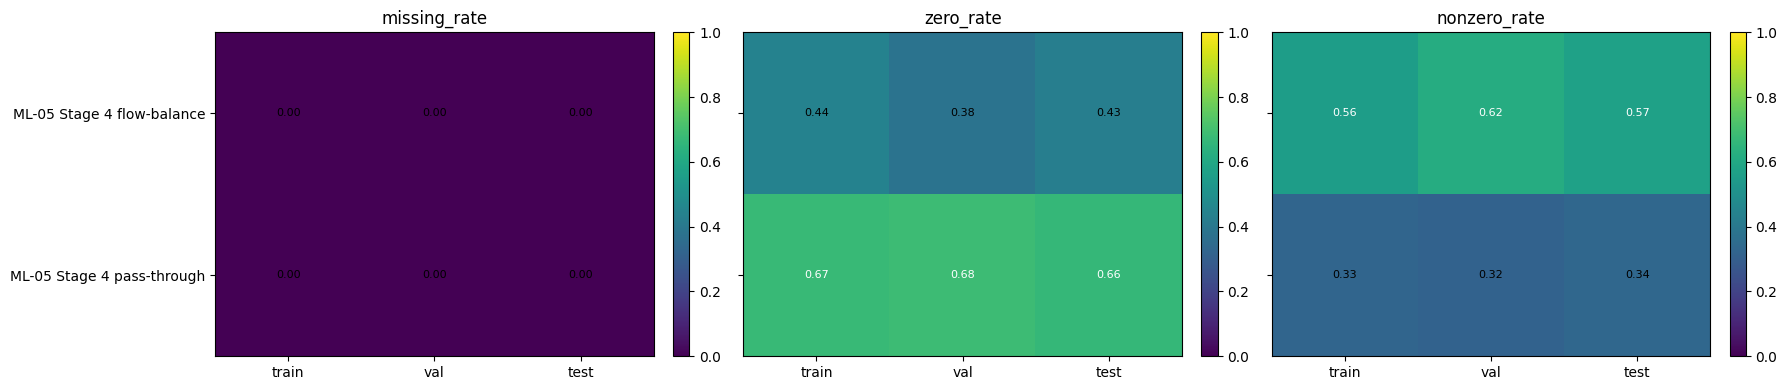

### Label separation by feature family

,stage_family,feature_count,mean_abs_std_mean_diff,max_abs_std_mean_diff,mean_abs_nonzero_lift
0,ML-05 Stage 4 flow-balance,32,0.046495,0.222001,0.064560
1,ML-05 Stage 4 pass-through,16,0.033734,0.098984,0.028756


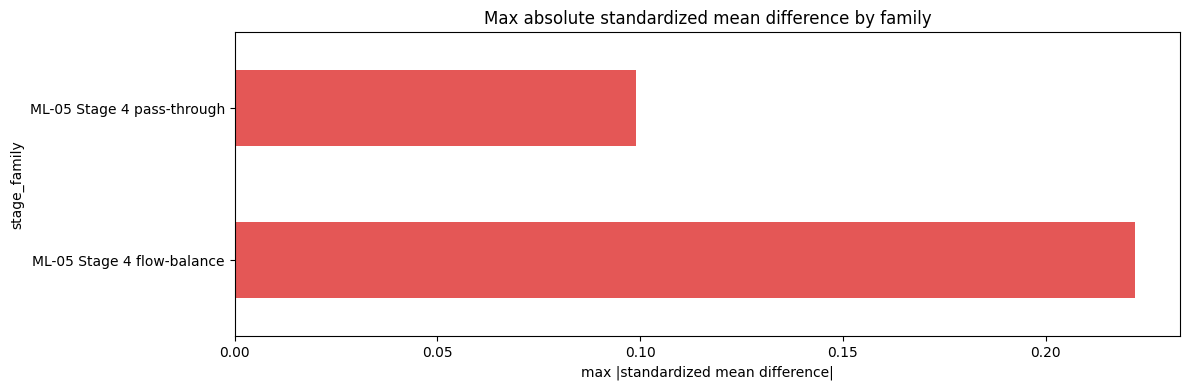

### Representative distribution plots by metric type

,distribution_plot_feature
0,flowbalance__receiver__net__amount__sumdiff__w7d
1,flowbalance__receiver__net__amount__sumdiff__w3d
2,flowbalance__receiver__net__amount__in_out_ratio__w7d
3,flowbalance__receiver__net__amount__sumdiff__w1d
4,flowbalance__sender__net__amount__in_out_ratio__w7d
5,passflow__sender__in_then_out__current_to_last_in_amount_ratio__w1h
6,passflow__sender__in_then_out__sequence_count__w1d
7,passflow__sender__in_then_out__sequence_count__w6h
8,passflow__sender__in_then_out__sequence_count__w1h
9,passflow__sender__in_then_out__seconds_since_last_in__w1h


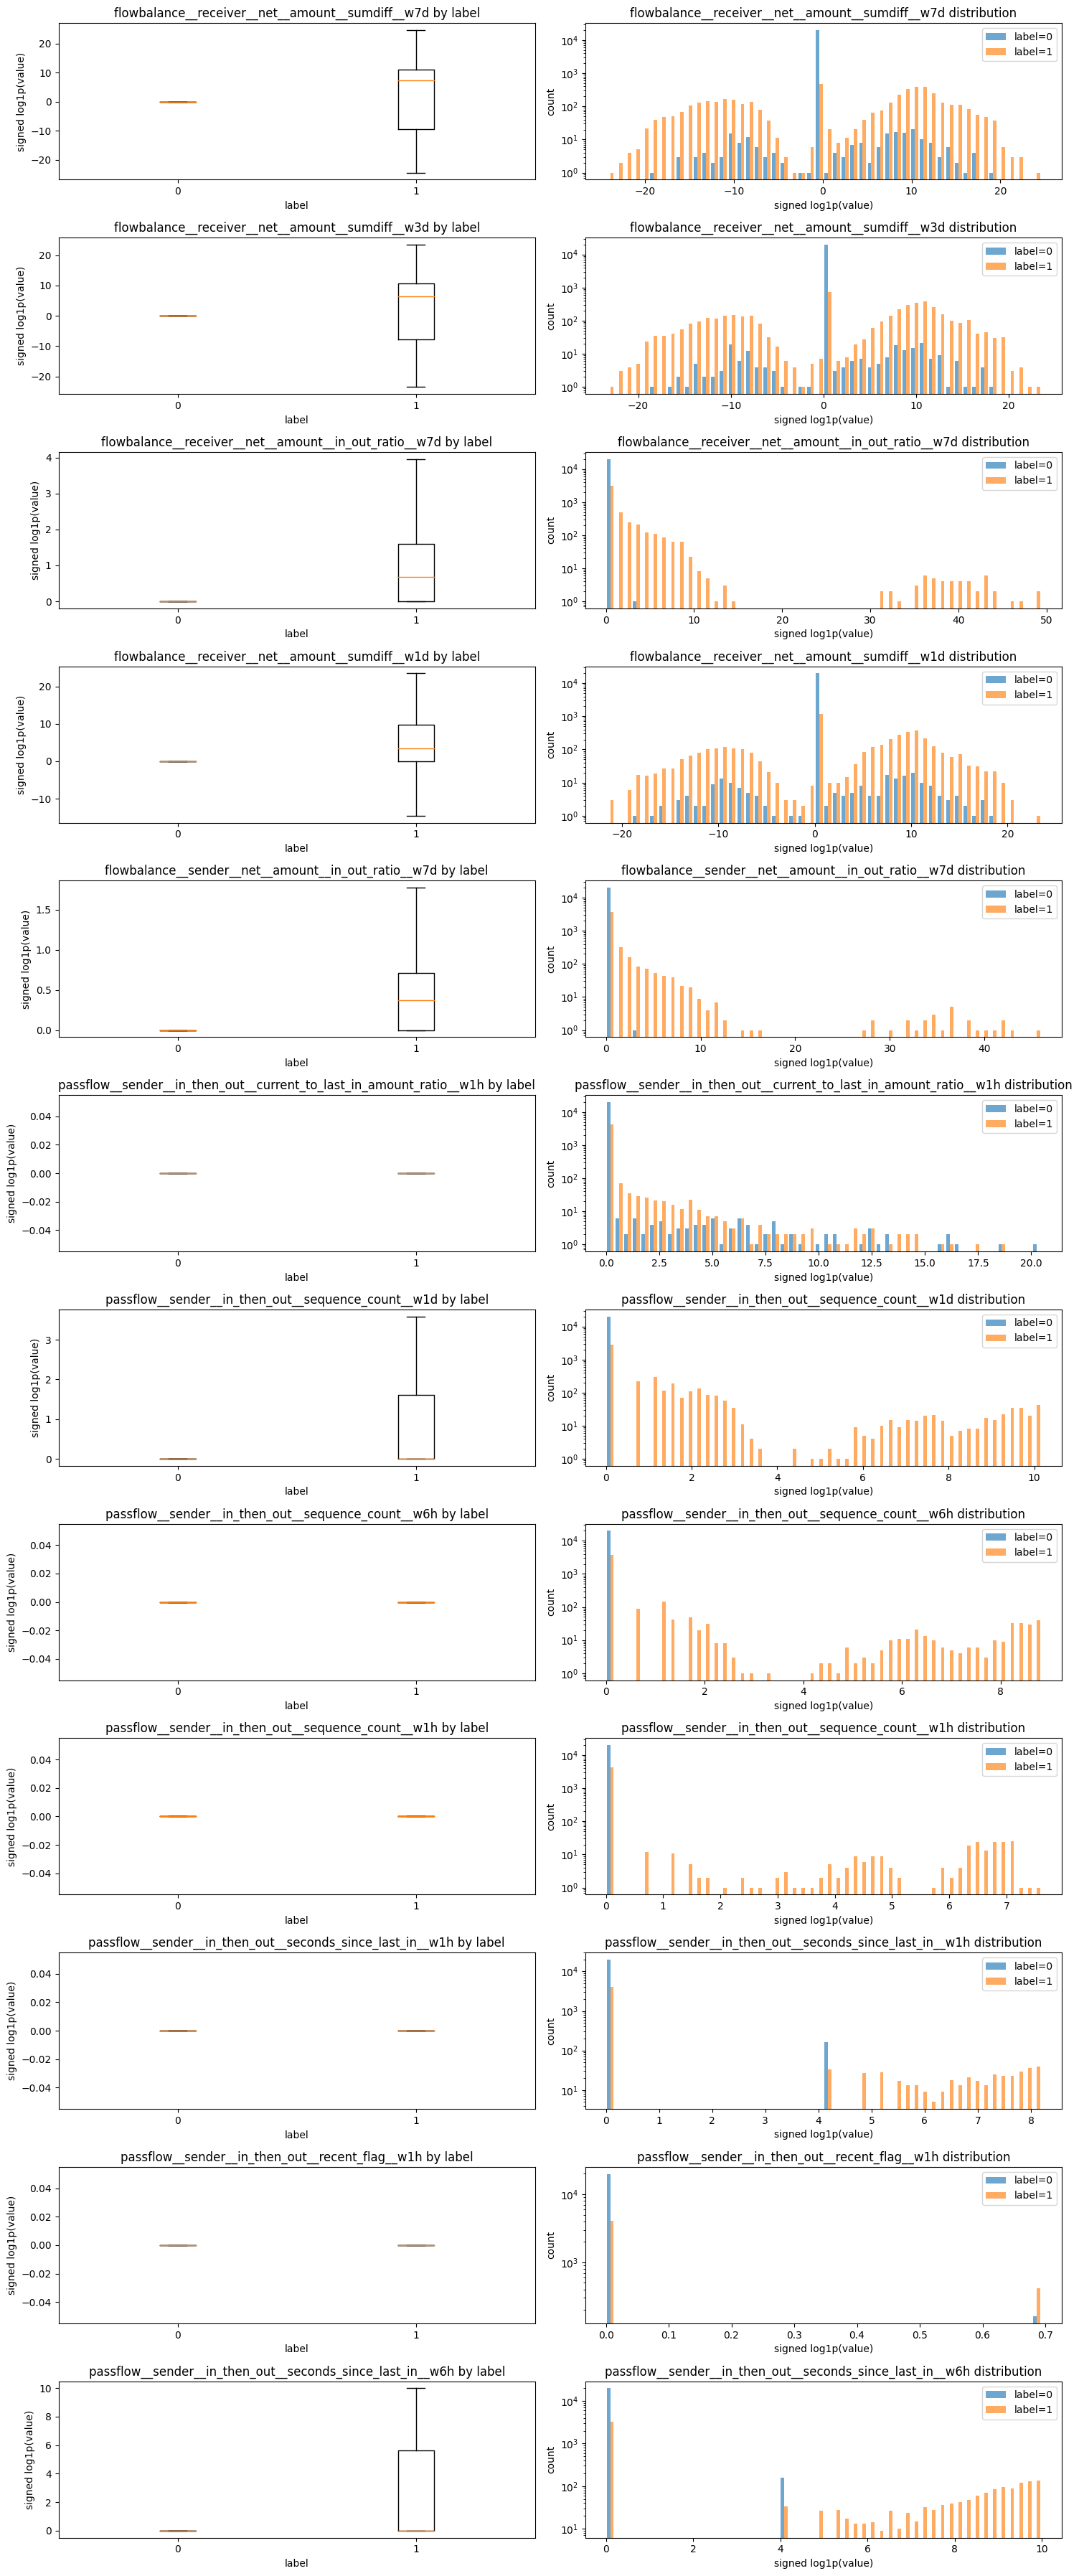

In [13]:
display(Markdown("## 13. Stage-aware feature interpretation visuals"))

display(Markdown("### Selected feature count by interpreted stage/family"))
family_count_df = (
    feature_review_catalog_df.groupby(["stage_family", "build_action"], dropna=False)
    .size()
    .reset_index(name="feature_count")
    .sort_values(["stage_family", "build_action"])
)
display(family_count_df)

if not family_count_df.empty:
    family_pivot = family_count_df.pivot_table(
        index="stage_family",
        columns="build_action",
        values="feature_count",
        fill_value=0,
        aggfunc="sum",
    )
    ax = family_pivot.plot(kind="barh", stacked=True, figsize=(12, max(5, len(family_pivot) * 0.45)))
    ax.set_title("Selected feature count by interpreted stage/family")
    ax.set_xlabel("selected feature count")
    ax.set_ylabel("stage_family")
    plt.tight_layout()
    plt.show()

display(Markdown("### Review priority with stage/family context"))
review_rank_enriched_df = add_feature_context(review_rank_df)
display(
    review_rank_enriched_df.sort_values("review_priority_score", ascending=False)
    .head(TOP_N)
    .reset_index(drop=True)
)

display(Markdown("### Family x split quality heatmap from per-feature scan"))
family_split_rows = []
if not review_split_df.empty:
    split_enriched = add_feature_context(review_split_df)
    for row in split_enriched.itertuples(index=False):
        for split in SPLIT_ORDER:
            family_split_rows.append(
                {
                    "stage_family": row.stage_family,
                    "split": split,
                    "missing_rate": getattr(row, f"{split}_missing_rate", np.nan),
                    "zero_rate": getattr(row, f"{split}_zero_rate", np.nan),
                    "nonzero_rate": getattr(row, f"{split}_nonzero_rate", np.nan),
                }
            )
family_split_quality_df = pd.DataFrame(family_split_rows)
if not family_split_quality_df.empty:
    family_split_summary_df = (
        family_split_quality_df.groupby(["stage_family", "split"], dropna=False)[["missing_rate", "zero_rate", "nonzero_rate"]]
        .mean()
        .reset_index()
    )
    display(family_split_summary_df)

    families_for_plot = family_split_summary_df["stage_family"].dropna().unique().tolist()
    metrics = ["missing_rate", "zero_rate", "nonzero_rate"]
    fig, axes = plt.subplots(1, 3, figsize=(18, max(4, len(families_for_plot) * 0.45)), sharey=True)
    for ax, metric in zip(axes, metrics):
        pivot = family_split_summary_df.pivot(index="stage_family", columns="split", values=metric).reindex(index=families_for_plot, columns=SPLIT_ORDER)
        im = ax.imshow(pivot.to_numpy(dtype=float), aspect="auto", cmap="viridis", vmin=0, vmax=1)
        ax.set_title(metric)
        ax.set_xticks(range(len(pivot.columns)))
        ax.set_xticklabels(pivot.columns)
        ax.set_yticks(range(len(pivot.index)))
        ax.set_yticklabels(pivot.index)
        for i in range(pivot.shape[0]):
            for j in range(pivot.shape[1]):
                value = pivot.iloc[i, j]
                if pd.notna(value):
                    ax.text(j, i, f"{value:.2f}", ha="center", va="center", color="white" if value > 0.5 else "black", fontsize=8)
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()
else:
    display(Markdown("family/split quality를 계산할 review_split_df가 비어 있습니다."))

display(Markdown("### Label separation by feature family"))
if not review_label_df.empty:
    label_enriched = add_feature_context(review_label_df)
    family_label_summary_df = (
        label_enriched.groupby("stage_family", dropna=False)
        .agg(
            feature_count=("column_name", "count"),
            mean_abs_std_mean_diff=("std_mean_diff", lambda s: float(s.abs().mean())),
            max_abs_std_mean_diff=("std_mean_diff", lambda s: float(s.abs().max())),
            mean_abs_nonzero_lift=("nonzero_rate_diff_l1_l0", lambda s: float(s.abs().mean())),
        )
        .reset_index()
        .sort_values("max_abs_std_mean_diff", ascending=False)
    )
    display(family_label_summary_df)

    ax = family_label_summary_df.plot(
        x="stage_family",
        y="max_abs_std_mean_diff",
        kind="barh",
        legend=False,
        figsize=(12, max(4, len(family_label_summary_df) * 0.42)),
        color="#E45756",
    )
    ax.set_title("Max absolute standardized mean difference by family")
    ax.set_xlabel("max |standardized mean difference|")
    ax.set_ylabel("stage_family")
    plt.tight_layout()
    plt.show()

display(Markdown("### Representative distribution plots by metric type"))
if not review_rank_enriched_df.empty:
    distribution_candidate_df = (
        review_rank_enriched_df.loc[review_rank_enriched_df["metric_type"].isin(["ratio_or_rate", "amount_or_balance", "flag", "count_or_degree", "time_gap"])]
        .sort_values("review_priority_score", ascending=False)
    )
    distribution_features = (
        distribution_candidate_df.groupby("metric_type", group_keys=False)
        .head(3)["column_name"]
        .drop_duplicates()
        .head(DIST_PLOT_FEATURE_LIMIT)
        .tolist()
    )
else:
    distribution_features = []

if not distribution_features:
    display(Markdown("분포 시각화 후보 feature를 찾지 못했습니다."))
else:
    display(pd.DataFrame({"distribution_plot_feature": distribution_features}))
    plot_sample_df = read_label_stratified_plot_sample(target_path, distribution_features, label_col)
    if plot_sample_df.empty:
        display(Markdown("분포 시각화용 sample을 읽지 못했습니다."))
    else:
        plot_sample_df[label_col] = pd.to_numeric(plot_sample_df[label_col], errors="coerce").fillna(-1).astype("int8")
        fig, axes = plt.subplots(len(distribution_features), 2, figsize=(15, max(4, len(distribution_features) * 3.0)))
        axes = np.atleast_2d(axes)
        for row_idx, feature in enumerate(distribution_features):
            plot_sample_df[feature] = pd.to_numeric(plot_sample_df[feature], errors="coerce").replace([np.inf, -np.inf], np.nan)
            values_by_label = [plot_sample_df.loc[plot_sample_df[label_col].eq(label), feature].dropna().to_numpy() for label in LABEL_ORDER]
            transformed_by_label = [signed_log1p_array(values) for values in values_by_label]

            axes[row_idx, 0].boxplot(transformed_by_label, labels=[str(label) for label in LABEL_ORDER], showfliers=False)
            axes[row_idx, 0].set_title(f"{feature} by label")
            axes[row_idx, 0].set_xlabel(label_col)
            axes[row_idx, 0].set_ylabel("signed log1p(value)")

            axes[row_idx, 1].hist(
                transformed_by_label,
                bins=50,
                label=[f"label={label}" for label in LABEL_ORDER],
                alpha=0.65,
                log=True,
            )
            axes[row_idx, 1].set_title(f"{feature} distribution")
            axes[row_idx, 1].set_xlabel("signed log1p(value)")
            axes[row_idx, 1].set_ylabel("count")
            axes[row_idx, 1].legend()
        plt.tight_layout()
        plt.show()


In [14]:
display(Markdown("## 14. Data reliability tables and correlation review"))

quality_detail_df = feature_review_catalog_df.copy()
if not feature_quality_df.empty:
    scan_quality_df = feature_quality_df.rename(
        columns={
            "missing_rate": "scan_missing_rate",
            "inf_count": "scan_inf_count",
            "zero_rate": "scan_zero_rate",
            "nonzero_rate": "scan_nonzero_rate",
        }
    )
    quality_detail_df = quality_detail_df.merge(scan_quality_df, on="column_name", how="left")
if feature_info_df is not None and not feature_info_df.empty and "column_name" in feature_info_df.columns:
    info_cols = [
        col
        for col in [
            "column_name",
            "rows",
            "missing_rate",
            "inf_count",
            "zero_rate",
            "unique_count",
            "near_zero_variance",
            "min",
            "median",
            "mean",
            "max",
            "computational_cost",
            "leakage_policy",
        ]
        if col in feature_info_df.columns
    ]
    info_quality_df = feature_info_df[info_cols].drop_duplicates("column_name").rename(
        columns={
            "missing_rate": "artifact_missing_rate",
            "inf_count": "artifact_inf_count",
            "zero_rate": "artifact_zero_rate",
            "near_zero_variance": "artifact_near_zero_variance",
            "leakage_policy": "artifact_leakage_policy",
        }
    )
    quality_detail_df = quality_detail_df.merge(info_quality_df, on="column_name", how="left")

for scan_col, artifact_col, output_col in [
    ("scan_missing_rate", "artifact_missing_rate", "missing_rate_review"),
    ("scan_inf_count", "artifact_inf_count", "inf_count_review"),
    ("scan_zero_rate", "artifact_zero_rate", "zero_rate_review"),
]:
    if scan_col in quality_detail_df.columns and artifact_col in quality_detail_df.columns:
        quality_detail_df[output_col] = quality_detail_df[scan_col].combine_first(quality_detail_df[artifact_col])
    elif scan_col in quality_detail_df.columns:
        quality_detail_df[output_col] = quality_detail_df[scan_col]
    elif artifact_col in quality_detail_df.columns:
        quality_detail_df[output_col] = quality_detail_df[artifact_col]
    else:
        quality_detail_df[output_col] = np.nan

if "artifact_near_zero_variance" in quality_detail_df.columns:
    quality_detail_df["near_zero_variance_review"] = quality_detail_df["artifact_near_zero_variance"].map(normalize_bool)
else:
    quality_detail_df["near_zero_variance_review"] = False

display(Markdown("### Top missing-rate features"))
display(
    quality_detail_df.sort_values("missing_rate_review", ascending=False)
    .head(TOP_N)
    .reset_index(drop=True)
)

display(Markdown("### Features with inf values"))
inf_review_df = quality_detail_df.loc[quality_detail_df["inf_count_review"].fillna(0) > 0].sort_values("inf_count_review", ascending=False)
display(inf_review_df.head(TOP_N).reset_index(drop=True) if not inf_review_df.empty else pd.DataFrame([{"status": "PASS", "detail": "No inf feature detected in reviewed columns"}]))

display(Markdown("### Top zero-rate and near-zero variance features"))
sparse_review_df = quality_detail_df.loc[
    quality_detail_df["zero_rate_review"].fillna(0).ge(READINESS_HIGH_ZERO_RATE) | quality_detail_df["near_zero_variance_review"]
].sort_values(["near_zero_variance_review", "zero_rate_review"], ascending=[False, False])
display(sparse_review_df.head(TOP_N).reset_index(drop=True) if not sparse_review_df.empty else pd.DataFrame([{"status": "PASS", "detail": "No high-zero or near-zero variance feature detected by configured thresholds"}]))

display(Markdown("### Top split drift features with context"))
if not review_split_df.empty:
    split_drift_context_df = add_feature_context(review_split_df)
    display(
        split_drift_context_df.sort_values("max_abs_signed_log1p_mean_gap_vs_train", ascending=False)
        .head(TOP_N)
        .reset_index(drop=True)
    )

display(Markdown("### Top label separation features with context"))
if not review_label_df.empty:
    label_context_df = add_feature_context(review_label_df)
    display(
        label_context_df.reindex(label_context_df["std_mean_diff"].abs().sort_values(ascending=False).index)
        .head(TOP_N)
        .reset_index(drop=True)
    )

display(Markdown("### Top correlated feature pairs"))
if not review_rank_enriched_df.empty:
    preferred_corr_candidates = review_rank_enriched_df.loc[
        review_rank_enriched_df["stage_family"].astype("string").str.contains("ML-05|Stage 5", regex=True, na=False)
    ].sort_values("review_priority_score", ascending=False)
    if len(preferred_corr_candidates) < 2:
        preferred_corr_candidates = review_rank_enriched_df.sort_values("review_priority_score", ascending=False)
    correlation_candidate_columns = preferred_corr_candidates["column_name"].drop_duplicates().head(CORR_FEATURE_LIMIT).tolist()
else:
    correlation_candidate_columns = corr_columns[:CORR_FEATURE_LIMIT]

if len(correlation_candidate_columns) >= 2:
    display(pd.DataFrame({"correlation_candidate_column": correlation_candidate_columns}))
    focused_corr_df = compute_streaming_corr(target_path, correlation_candidate_columns)
    focused_corr_pairs_df = top_correlation_pairs(focused_corr_df)
    display(focused_corr_pairs_df if not focused_corr_pairs_df.empty else pd.DataFrame([{"status": "INFO", "detail": "No finite correlation pair was computed"}]))
    if not focused_corr_df.empty and len(focused_corr_df) <= 30:
        fig, ax = plt.subplots(figsize=(max(9, len(focused_corr_df) * 0.35), max(8, len(focused_corr_df) * 0.35)))
        im = ax.imshow(focused_corr_df.to_numpy(), cmap="coolwarm", vmin=-1, vmax=1)
        ax.set_title("Focused feature correlation")
        ax.set_xticks(range(len(focused_corr_df.columns)))
        ax.set_yticks(range(len(focused_corr_df.index)))
        ax.set_xticklabels(focused_corr_df.columns, rotation=90, fontsize=7)
        ax.set_yticklabels(focused_corr_df.index, fontsize=7)
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        plt.tight_layout()
        plt.show()
else:
    display(pd.DataFrame([{"status": "INFO", "detail": "Not enough numeric candidate features for correlation review"}]))


## 14. Data reliability tables and correlation review

### Top missing-rate features

,column_name,used_in_ml,feature_group,feature_spec_name,build_action,encoding,leakage_risk,review_status,selection_note,stage_family,metric_type,forbidden_name_hits,has_forbidden_name_hit,scan_missing_rate,scan_inf_count,scan_zero_rate,scan_nonzero_rate,rows,artifact_missing_rate,artifact_inf_count,artifact_zero_rate,unique_count,artifact_near_zero_variance,min,median,mean,max,computational_cost,artifact_leakage_policy,missing_rate_review,inf_count_review,zero_rate_review,near_zero_variance_review
0,flowbalance__sender__net__amount__in_out_ratio__w6h,True,flowbalance,flowbalance_window,build,passthrough,past-only; history_timestamp < current_timestamp; same-timestamp rows excluded,approved,user selected Stage 4 flow-balance/pass-through feature,ML-05 Stage 4 flow-balance,ratio_or_rate,[],False,0.0,0.0,0.753572,0.246428,5077237.0,0.0,0.0,0.753572,828130.0,False,0.000000e+00,0.000000,2.224121e+16,1.142719e+22,low,past-only; history_timestamp < current_timestamp; same-timestamp rows excluded,0.0,0.0,0.753572,False
1,flowbalance__sender__net__amount__sumdiff__w6h,True,flowbalance,flowbalance_window,build,passthrough,past-only; history_timestamp < current_timestamp; same-timestamp rows excluded,approved,user selected Stage 4 flow-balance/pass-through feature,ML-05 Stage 4 flow-balance,amount_or_balance,[],False,0.0,0.0,0.337422,0.662578,5077237.0,0.0,0.0,0.337422,1706748.0,False,-1.012953e+12,-117.470001,-1.568423e+08,1.013024e+12,low,past-only; history_timestamp < current_timestamp; same-timestamp rows excluded,0.0,0.0,0.337422,False
2,flowbalance__receiver__net__amount__residual_abs__w3d,True,flowbalance,flowbalance_window,build,passthrough,past-only; history_timestamp < current_timestamp; same-timestamp rows excluded,approved,user selected Stage 4 flow-balance/pass-through feature,ML-05 Stage 4 flow-balance,amount_or_balance,[],False,0.0,0.0,0.127285,0.872715,5077237.0,0.0,0.0,0.127285,2925771.0,False,0.000000e+00,15343.700195,7.005062e+07,1.046509e+12,low,past-only; history_timestamp < current_timestamp; same-timestamp rows excluded,0.0,0.0,0.127285,False
3,flowbalance__receiver__net__amount__balanced_state_flag__w3d,True,flowbalance,flowbalance_window,build,passthrough,past-only; history_timestamp < current_timestamp; same-timestamp rows excluded,approved,user selected Stage 4 flow-balance/pass-through feature,ML-05 Stage 4 flow-balance,amount_or_balance,[],False,0.0,0.0,0.855133,0.144867,5077237.0,0.0,0.0,0.855133,2.0,False,0.000000e+00,0.000000,1.448672e-01,1.000000e+00,low,past-only; history_timestamp < current_timestamp; same-timestamp rows excluded,0.0,0.0,0.855133,False
4,flowbalance__receiver__net__amount__in_out_ratio__w7d,True,flowbalance,flowbalance_window,build,passthrough,past-only; history_timestamp < current_timestamp; same-timestamp rows excluded,approved,user selected Stage 4 flow-balance/pass-through feature,ML-05 Stage 4 flow-balance,ratio_or_rate,[],False,0.0,0.0,0.245378,0.754622,5077237.0,0.0,0.0,0.245378,3311756.0,False,0.000000e+00,1.000000,1.083174e+18,1.585744e+23,low,past-only; history_timestamp < current_timestamp; same-timestamp rows excluded,0.0,0.0,0.245378,False
5,flowbalance__receiver__net__amount__sumdiff__w7d,True,flowbalance,flowbalance_window,build,passthrough,past-only; history_timestamp < current_timestamp; same-timestamp rows excluded,approved,user selected Stage 4 flow-balance/pass-through feature,ML-05 Stage 4 flow-balance,amount_or_balance,[],False,0.0,0.0,0.117369,0.882631,5077237.0,0.0,0.0,0.117369,3678739.0,False,-1.485909e+12,4358.129883,-1.402716e+06,1.460085e+12,low,past-only; history_timestamp < current_timestamp; same-timestamp rows excluded,0.0,0.0,0.117369,False
6,flowbalance__receiver__net__amount__residual_abs__w7d,True,flowbalance,flowbalance_window,build,passthrough,past-only; history_timestamp < current_timestamp; same-timestamp rows excluded,approved,user selected Stage 4 flow-balance/pass-through feature,ML-05 Stage 4 flow-balance,amount_or_balance,[],False,0.0,0.0,0.1

### Features with inf values

,status,detail
0,PASS,No inf feature detected in reviewed columns


...

### Top label separation features with context

,column_name,mean_label0,mean_label1,mean_ratio_label1_over_label0,std_mean_diff,nonzero_rate_label0,nonzero_rate_label1,nonzero_rate_diff_l1_l0,stage_family,metric_type,feature_group,build_action
0,flowbalance__sender__net__amount__balanced_state_flag__w7d,1.730622e-01,2.642636e-01,1.526987,0.222001,0.173062,0.264264,0.091201,ML-05 Stage 4 flow-balance,amount_or_balance,flowbalance,build
1,flowbalance__receiver__net__amount__balanced_state_flag__w6h,1.272587e-01,7.806280e-02,0.613418,-0.162622,0.127259,0.078063,-0.049196,ML-05 Stage 4 flow-balance,amount_or_balance,flowbalance,build
2,flowbalance__receiver__net__amount__balanced_state_flag__w3d,1.449084e-01,9.862893e-02,0.680629,-0.141875,0.144908,0.098629,-0.046279,ML-05 Stage 4 flow-balance,amount_or_balance,flowbalance,build
3,flowbalance__sender__net__amount__balanced_state_flag__w6h,1.521000e-01,1.052632e-01,0.692065,-0.140219,0.152100,0.105263,-0.046837,ML-05 Stage 4 flow-balance,amount_or_balance,flowbalance,build
4,flowbalance__receiver__net__amount__balanced_state_flag__w1d,1.536136e-01,1.158779e-01,0.754347,-0.110684,0.153614,0.115878,-0.037736,ML-05 Stage 4 flow-balance,amount_or_balance,flowbalance,build
5,passflow__sender__in_then_out__sequence_count__w1d,4.019002e+02,6.879560e+02,1.711758,0.098984,0.563593,0.391199,-0.172394,ML-05 Stage 4 pass-through,count_or_degree,passflow,build
6,passflow__sender__in_then_out__sequence_count__w6h,1.059437e+02,1.773691e+02,1.674183,0.089505,0.210287,0.150376,-0.059911,ML-05 Stage 4 pass-through,count_or_degree,passflow,build
7,passflow__sender__in_then_out__sequence_count__w1h,1.597232e+01,2.770743e+01,1.734716,0.085252,0.061230,0.053074,-0.008156,ML-05 Stage 4 pass-through,count_or_degree,passflow,build
8,flowbalance__sender__net__amount__sumdiff__w7d,-2.633432e+09,-3.966941e+09,1.506377,-0.072313,0.875986,0.875719,-0.000268,ML-05 Stage 4 flow-balance,amount_or_balance,flowbalance,build
9,flowbalance__sender__net__amount__residual_abs__w7d,2.701625e+09,3.975743e+09,1.471612,0.069115,0.875986,0.875719,-0.000268,ML-05 Stage 4 flow-balance,amount_or_balance,flowbalance,build


### Top correlated feature pairs

,correlation_candidate_column
0,flowbalance__receiver__net__amount__sumdiff__w7d
1,flowbalance__receiver__net__amount__sumdiff__w3d
2,flowbalance__receiver__net__amount__in_out_ratio__w7d
3,flowbalance__receiver__net__amount__sumdiff__w1d
4,flowbalance__receiver__net__amount__sumdiff__w6h
5,flowbalance__sender__net__amount__in_out_ratio__w7d
6,passflow__sender__in_then_out__current_to_last_in_amount_ratio__w1h
7,passflow__sender__in_then_out__current_to_last_in_amount_ratio__w6h
8,passflow__sender__in_then_out__current_to_last_in_amount_ratio__w1d
9,passflow__sender__in_then_out__sequence_count__w1d


,feature_a,feature_b,corr,abs_corr
0,passflow__receiver__in_then_out__historical_sequence_count__w1d,passflow__receiver__in_then_out__historical_sequence_count__w3d,0.979314,0.979314
1,passflow__sender__in_then_out__current_to_last_in_amount_ratio__w6h,passflow__sender__in_then_out__current_to_last_in_amount_ratio__w1d,0.968276,0.968276
2,passflow__receiver__in_then_out__historical_sequence_count__w1d,passflow__receiver__in_then_out__historical_sequence_count__w6h,0.952194,0.952194
3,flowbalance__receiver__net__amount__residual_abs__w6h,flowbalance__receiver__net__amount__residual_abs__w1d,0.922737,0.922737
4,flowbalance__receiver__net__amount__sumdiff__w1d,flowbalance__receiver__net__amount__sumdiff__w6h,0.922732,0.922732
5,flowbalance__sender__net__amount__sumdiff__w7d,flowbalance__sender__net__amount__residual_abs__w7d,-0.919744,0.919744
6,passflow__receiver__in_then_out__historical_sequence_count__w6h,passflow__receiver__in_then_out__historical_sequence_count__w3d,0.914621,0.914621
7,passflow__sender__in_then_out__current_to_last_in_amount_ratio__w1h,passflow__sender__in_then_out__current_to_last_in_amount_ratio__w6h,0.888199,0.888199
8,passflow__sender__in_then_out__sequence_count__w1d,passflow__sender__in_then_out__sequence_count__w6h,0.884676,0.884676
9,flowbalance__receiver__net__amount__sumdiff__w3d,flowbalance__receiver__net__amount__sumdiff__w1d,0.869063,0.869063


In [15]:
display(Markdown("## 15. Leakage and split-time boundary review"))

display(Markdown("### Target-like or forbidden feature names"))
forbidden_name_review_df = feature_review_catalog_df.loc[feature_review_catalog_df["has_forbidden_name_hit"]].copy()
display(
    forbidden_name_review_df[["column_name", "stage_family", "metric_type", "forbidden_name_hits", "feature_group", "build_action"]]
    .reset_index(drop=True)
    if not forbidden_name_review_df.empty
    else pd.DataFrame([{"status": "PASS", "detail": "No selected feature name matched target-like forbidden patterns"}])
)

display(Markdown("### Contract leakage fields requiring manual review"))
leakage_review_rows = []
if contract_df is None:
    leakage_review_rows.append(
        {
            "status": "WARN",
            "column_name": None,
            "field": "contract",
            "detail": "No contract artifact was loaded; leakage metadata cannot be reviewed",
        }
    )
else:
    leakage_fields = [field for field in ["leakage_risk", "leakage_policy", "leakage_check"] if field in selected_contract_df.columns]
    if not leakage_fields:
        leakage_review_rows.append(
            {
                "status": "WARN",
                "column_name": None,
                "field": "leakage_metadata",
                "detail": "Selected contract has no leakage_risk/leakage_policy/leakage_check field",
            }
        )
    else:
        selected_contract_unique = selected_contract_df.drop_duplicates("column_name")
        for row in selected_contract_unique.itertuples(index=False):
            column_name = text_value(getattr(row, "column_name", ""))
            for field in leakage_fields:
                value = text_value(getattr(row, field, "")).strip()
                normalized = value.lower()
                if value == "" or normalized in {"nan", "none", "<na>"}:
                    leakage_review_rows.append(
                        {
                            "status": "WARN",
                            "column_name": column_name,
                            "field": field,
                            "detail": "blank leakage metadata",
                        }
                    )
                else:
                    hits = [pattern for pattern in SUSPICIOUS_LEAKAGE_TEXT_PATTERNS if pattern in normalized]
                    if hits:
                        leakage_review_rows.append(
                            {
                                "status": "WARN",
                                "column_name": column_name,
                                "field": field,
                                "detail": f"suspicious leakage text patterns={hits}; value={value}",
                            }
                        )
leakage_review_df = pd.DataFrame(leakage_review_rows)
display(leakage_review_df.head(TOP_N).reset_index(drop=True) if not leakage_review_df.empty else pd.DataFrame([{"status": "PASS", "detail": "No blank or suspicious leakage metadata detected in selected contract fields"}]))

display(Markdown("### Exact split timestamp ranges"))
split_time_range_df, split_time_boundary_df = scan_split_time_ranges(target_path, split_col, time_col)
display(split_time_range_df)
display(split_time_boundary_df)

display(Markdown("### Final pre-ML interpretation"))
error_count = int((readiness_df["status"] == "ERROR").sum()) if "readiness_df" in globals() else 0
warn_count = int((readiness_df["status"] == "WARN").sum()) if "readiness_df" in globals() else 0
boundary_error_count = int((split_time_boundary_df["status"] == "ERROR").sum()) if not split_time_boundary_df.empty else 0
boundary_warn_count = int((split_time_boundary_df["status"] == "WARN").sum()) if not split_time_boundary_df.empty else 0
leakage_warn_count = int((leakage_review_df["status"] == "WARN").sum()) if not leakage_review_df.empty and "status" in leakage_review_df.columns else 0

blocking_count = error_count + boundary_error_count
manual_review_count = warn_count + boundary_warn_count + leakage_warn_count
if blocking_count > 0:
    final_status = "BLOCKED"
    final_detail = "ERROR 항목이 있어 ML 학습 투입 전 수정 또는 재생성이 필요하다."
elif manual_review_count > 0:
    final_status = "REVIEW_REQUIRED"
    final_detail = "자동 차단 항목은 없지만 WARN 항목을 사람이 확인한 뒤 학습 투입 여부를 결정한다."
else:
    final_status = "READY_WITH_MANUAL_SIGNOFF"
    final_detail = "자동 점검 기준으로 차단 항목은 없으며, 최종 학습 투입 전 사람 검토만 남았다."

display(
    pd.DataFrame(
        [
            {
                "final_status": final_status,
                "blocking_error_count": blocking_count,
                "manual_review_warning_count": manual_review_count,
                "detail": final_detail,
                "important_note": "이 표는 자동 보조 판단이며, 누수 생성 로직과 feature 의미 검토를 대체하지 않는다.",
            }
        ]
    )
)


## 15. Leakage and split-time boundary review

### Target-like or forbidden feature names

,status,detail
0,PASS,No selected feature name matched target-like forbidden patterns


### Contract leakage fields requiring manual review

,status,detail
0,PASS,No blank or suspicious leakage metadata detected in selected contract fields


### Exact split timestamp ranges

,split,min_timestamp,max_timestamp,rows_with_timestamp
0,train,2022-09-01 00:00:00,2022-09-06 13:33:00,3046186
1,val,2022-09-06 13:34:00,2022-09-08 16:09:00,1015633
2,test,2022-09-08 16:10:00,2022-09-10 23:59:00,1015418


,boundary,status,left_max_timestamp,right_min_timestamp,detail
0,train->val,PASS,2022-09-06 13:33:00,2022-09-06 13:34:00,strictly ordered; no range overlap
1,val->test,PASS,2022-09-08 16:09:00,2022-09-08 16:10:00,strictly ordered; no range overlap


### Final pre-ML interpretation

,final_status,blocking_error_count,manual_review_warning_count,detail,important_note
0,READY_WITH_MANUAL_SIGNOFF,0,0,"자동 점검 기준으로 차단 항목은 없으며, 최종 학습 투입 전 사람 검토만 남았다.","이 표는 자동 보조 판단이며, 누수 생성 로직과 feature 의미 검토를 대체하지 않는다."
